# Baseline Model

## Table of Contents
1. [Feature Selection](#ovsQ2KQ0AYiG)
2. [Model Choice](#hbeVhkOpAYiG)
    * [Simple linear models](#__LRqKk6e3wg)
        * [Full set of features](#7rD5agvgAYiI)
        * [Restricted set of features](#xx0UVbQYLQbo)
    * [Flexible models](#J9fgNII7fF4M)
        * [Full set of features](#cJAsmhNnLYzI)
        * [Restricted set of features](#vJRCTrJYUP-t)
3. [Evaluation of the baseline model](#mwy-t-DPAYiJ)
    * [Comparison of baseline models](#V1PSxXg2hLxi)
    * [Comparison of flexible models](#BONFZ_U6Xnit)
4. [Analysis](#whGBO5XCdqFo)
    * [Average treatment effect (ATE)](#01a9ce2e)
    * [Conditional average treatment effect (CATE)](#cnmX4igFgpDa)
        * [CATE distribution by 'black' dummy variable](#db1f95ba)
        * [CATE distribution by 'education' variable](#a548874b)
        * [Distributions of $m_0(X)$ and $m_1(X)$](#96548f63)
5. [Resources](#)

In [ ]:
# Import necessary libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, mean_squared_error
import statsmodels.api as sm # to model and simple statistical models (like OLS)
import sklearn.linear_model as lm # for simple ML models (Lasso / Ridge)
import statsmodels.formula.api as smf # for easy model specification ("R-style")
from sklearn.preprocessing import StandardScaler # to use "StandardScaler"
from sklearn.pipeline import Pipeline # for processing ML models
from sklearn.metrics import r2_score

!pip install causaldata
import causaldata

import warnings
# ignore potential convergence warnings; for some small penalty levels,
# tried out, optimization might not converge
warnings.simplefilter('ignore')

## Feature Selection

[Indicate which features from the dataset you will be using for the baseline model, and justify your selection.]


In [ ]:
# Load the dataset
df = causaldata.nsw_mixtape.load_pandas().data

# Feature selection

# only use those participant who actually took part in the final survey:
# drop those with re78 ==0
#df = df[df['re78'] !=0] --> do not exclude, assume that these people were just unemployed at during this survey

# only keep those who answered all surveys
#df = df[df['re75'] != 0]
#df = df[df['re74'] != 0]

# Handle zeros in re78 before taking log to avoid -inf values
ly78 = np.log(df['re78'] + 1) # Add 1 to re78 to handle zeros before logging
ly75 = np.log(df['re75'] + 1) # Add 1 to re75 to handle zeros before logging
ly74 = np.log(df['re74'] + 1) # Add 1 to re74 to handle zeros before logging

df['lre78'] = ly78 # Add log(re78) as a new column to the DataFrame
df['lre75'] = ly75 # Add log(re75) as a new column to the DataFrame
df['lre74'] = ly74 # Add log(re74) as a new column to the DataFrame


# Models with all features
X = df[['age', 'educ', 'black', 'hisp', 'marr', 'nodegree', 'lre75', 'lre74']] # previous years of income enter as controls for pre-trends

# Splitting the dataset
X_train, X_test, y_train, y_test = train_test_split(X, df['lre78'], test_size=0.2, random_state=42)

In [ ]:
X.head()

,age,educ,black,hisp,marr,nodegree,lre75,lre74
0,37,11,1,0,1,1,0.0,0.0
1,22,9,0,1,0,1,0.0,0.0
2,30,12,1,0,0,0,0.0,0.0
3,27,11,1,0,0,1,0.0,0.0
4,33,8,1,0,0,1,0.0,0.0


In [ ]:
df.shape

(445, 14)

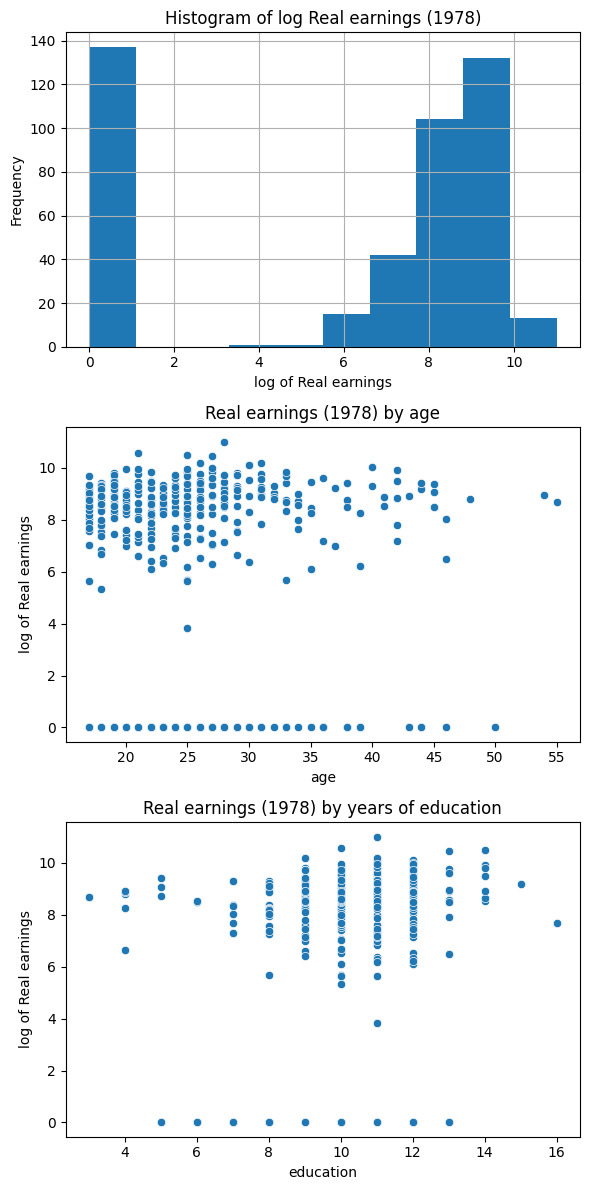

In [ ]:
# graph of data
import seaborn as sns
import matplotlib.pyplot as plt

# Create a figure with three subplots
fig, axes = plt.subplots(3, 1, figsize=(6, 12)) # Changed to 3 rows to accommodate the histogram

# Plot 0: Histogram of lre78
df['lre78'].hist(ax=axes[0])
axes[0].set_title('Histogram of log Real earnings (1978)')
axes[0].set_xlabel('log of Real earnings')
axes[0].set_ylabel('Frequency')

# Plot 1: Scatter plot of lre78 vs age
sns.scatterplot(data=df, x="age", y="lre78", ax=axes[1])
axes[1].set_title('Real earnings (1978) by age')
axes[1].set_xlabel('age')
axes[1].set_ylabel('log of Real earnings')

# Plot 2: Scatter plot of lre78 vs educ
sns.scatterplot(data=df, x="educ", y="lre78", ax=axes[2])
axes[2].set_title('Real earnings (1978) by years of education')
axes[2].set_xlabel('education')
axes[2].set_ylabel('log of Real earnings')

# Adjust the spacing between subplots
plt.tight_layout() # Adjust layout to prevent labels from being cut off
plt.show()

## Model Choice

[Explain why you've chosen a particular model as the baseline. This could be a simple statistical model or a basic machine learning model. Justify your choice.]


### Simple linear models

#### Full set of features



In [ ]:
#OLS
import statsmodels.api as sm
import statsmodels.formula.api as smf
from sklearn.metrics import mean_squared_error

# Initialize and train the baseline OLS model
model_base= 'lre78 ~ age + educ + C(black) + C(hisp) + C(marr) + C(nodegree) + lre75 + lre74'

OLS_base = smf.ols(model_base, data=df)

# model.fit(X_train, y_train) on training sample
results_OLS_base = sm.OLS(y_train, X_train).fit()

# predict on test sample
y_pred_OLS_base = results_OLS_base.predict(X_test)

# evaluate fit
MSE_OLS_base = mean_squared_error(y_test, y_pred_OLS_base)
R2_OLS_base = results_OLS_base.rsquared_adj

 Checking for Sparse or Dense Signal Environment

To determine if the data environment is sparse or dense, we can examine the proportion of zero values within the feature matrices (`X` for the baseline model and `X_full` for the flexible model). A high percentage of zeros indicates a sparse environment.

In [ ]:
# Calculate the percentage of zero values in the baseline feature matrix (X)
percentage_zeros_X = np.mean(X == 0) * 100
print(f"Percentage of zero values in the baseline feature matrix (X): {percentage_zeros_X:.2f}%")


Percentage of zero values in the baseline feature matrix (X): 43.88%


more than 50% of the matrix is zero values, hence rather dense. Do Ridge regression

ALWAYS explain in the first section here why I fit the corresponding model (why elastic net / why LASSO usw.)

In [ ]:
# set up formula for calculation or adjusted R-squared

def adjusted_r_squared(y_true, y_pred, num_features):
    r2 = r2_score(y_true, y_pred)
    n = len(y_true)
    k = num_features

    # Formel für Adjusted R-squared
    adj_r2 = 1 - ((1 - r2) * (n - 1) / (n - k - 1))
    return adj_r2

In [ ]:
# Ridge regression
ridge_base = Pipeline([('scale', StandardScaler()),  # standardize the variables
                  ('ridge', lm.RidgeCV())])

# Fit with the full X_train for the base model (6 features)
results_ridge_base = ridge_base.fit(X_train, y_train)

y_pred_ridge_base = results_ridge_base.predict(X_test)


# calculating out-of-sample MSE
MSE_RIDGE_base=mean_squared_error(y_test, y_pred_ridge_base)
R2_RIDGE_base = adjusted_r_squared(y_test, y_pred_ridge_base,6) # 6 features in baseline model


print(f"Best alpha found by RidgeCV for baseline: {ridge_base.named_steps['ridge'].alpha_:.4f}")
print(f"Test MSE for the Ridge baseline model: {MSE_RIDGE_base:.4f}")
print(f"Test adjusted R2 for the Ridge baseline model: {R2_RIDGE_base:.4f}")

Best alpha found by RidgeCV for baseline: 10.0000
Test MSE for the Ridge baseline model: 16.8812
Test adjusted R2 for the Ridge baseline model: -0.0632


Still, as we don't have high-dimensional data, I will additionally fit LASSO and post-LASSO regressions.

In [ ]:
# LASSO regression
lasso_base = Pipeline([('scale', StandardScaler()),  # standardize the variables
                  ('lasso', lm.LassoCV())])

# Fit with the full X_train for the base model (6 features)
results_lasso_base = lasso_base.fit(X_train, y_train)

y_pred_lasso_base = results_lasso_base.predict(X_test)


# calculating out-of-sample MSE
MSE_LASSO_base=mean_squared_error(y_test, y_pred_lasso_base)
R2_LASSO_base = adjusted_r_squared(y_test, y_pred_lasso_base, 6)

print(f"Test MSE for the LASSO baseline model: {MSE_LASSO_base:.4f}")
print(f"Test adjusted R2 for the LASSO baseline model: {R2_LASSO_base:.4f}")

Test MSE for the LASSO baseline model: 16.6414
Test adjusted R2 for the LASSO baseline model: -0.0481


Additionally, I will try post-LASSO models to eliminate shrinkage bias introduced by LASSO estimation.

In [ ]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import statsmodels.formula.api as smf
from sklearn.linear_model import LassoCV
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# post-LASSO OLS
# Re-perform the baseline data split to ensure X_train_baseline and y_train_baseline are correct
# This is crucial as X_train and y_train might have been overwritten by flexible model splits.
X_train_baseline, X_test_baseline, y_train_baseline, y_test_baseline = train_test_split(
    X, df['lre78'], test_size=0.2, random_state=42 # Use original X and ly78 for baseline
)

lasso_base = Pipeline([('scale', StandardScaler()), ('lasso', LassoCV())])
results_lasso_base = lasso_base.fit(X_train_baseline, y_train_baseline)

# Extract selected features from the LASSO baseline model
lasso_model_base = lasso_base.named_steps['lasso']
lasso_coefficients_base = lasso_model_base.coef_
feature_names_base = X.columns.tolist() # X contains 'age', 'educ', 'black', 'hisp', 'marr', 'nodegree'

# Ensure coefficients and feature names have the same length
# If a coefficient is exactly zero due to LASSO, it might not be explicitly present if a different
# mechanism for feature names was used. However, .coef_ should always return for all input features.
# Filter out features with 0 coefficient and their corresponding names

# Check for length consistency before creating DataFrame
if len(feature_names_base) != len(lasso_coefficients_base):
    print(f"Warning: Mismatch in feature names ({len(feature_names_base)}) and coefficients ({len(lasso_coefficients_base)}) length.")
    # Attempt to align by taking the first 'n' coefficients where n is feature_names_base length
    # This assumes that the excess coefficients are due to some design matrix expansion not intended for baseline
    # For a clean fit on X_train_baseline, this block ideally shouldn't be hit.
    if len(lasso_coefficients_base) > len(feature_names_base):
        lasso_coefficients_base = lasso_coefficients_base[:len(feature_names_base)]
    else:
        raise ValueError("Coefficient array is unexpectedly shorter than feature names.")

coef_df_base = pd.DataFrame({'Feature': feature_names_base, 'Coefficient': lasso_coefficients_base})
selected_features_df_base = coef_df_base[coef_df_base['Coefficient'] != 0].sort_values(by='Coefficient', ascending=False)

print("Features selected by LASSO for the BASELINE model and their coefficients (on scaled data):")
display(selected_features_df_base)
print("\nNumber of selected features for the BASELINE model:", len(selected_features_df_base))

selected_features_raw_base = selected_features_df_base['Feature'].tolist()

# Adapt cleaning function for baseline model's features to patsy formula format
def format_baseline_feature_for_patsy(feature_name):
    # These are the categorical features explicitly handled as such in the baseline OLS formula
    if feature_name in ['black', 'hisp', 'marr', 'nodegree']:
        return f'C({feature_name})'
    return feature_name

cleaned_selected_features_for_formula_base = [format_baseline_feature_for_patsy(f) for f in selected_features_raw_base]

# Handle the case where no features are selected by LASSO
if not cleaned_selected_features_for_formula_base:
    model_formula_rhs_post_lasso_base = "1" # Patsy formula for intercept only
else:
    model_formula_rhs_post_lasso_base = " + ".join(cleaned_selected_features_for_formula_base)

model_restrict_post_lasso_base = f'lre78 ~ {model_formula_rhs_post_lasso_base}'

print(f"\nPost-LASSO OLS Baseline Model Formula: {model_restrict_post_lasso_base}")

# Generate the design matrix for the restricted model based on the full dataset
# Note: This uses the original 'df' for model formula interpretation, ensuring correct design matrix generation
tmp_restrict_base = smf.ols(model_restrict_post_lasso_base, data=df)
X_full_restrict_base = tmp_restrict_base.data.exog
y_full_restrict_base = tmp_restrict_base.data.endog

# Split the restricted data using the same test_size and random_state as the initial split
X_train_restrict_base, X_test_restrict_base, y_train_restrict_base, y_test_restrict_base = train_test_split(
    X_full_restrict_base, y_full_restrict_base, test_size=0.2, shuffle=True, random_state=42 # Use same random_state as initial split
)

# Fit OLS model on the training data of the restricted set
results_OLS_post_lasso_base = sm.OLS(y_train_restrict_base, X_train_restrict_base).fit()

# Predict on the test data of the restricted set
y_pred_OLS_post_lasso_base = results_OLS_post_lasso_base.predict(X_test_restrict_base)

# Evaluate OLS Model fit
MSE_OLS_post_lasso_base = mean_squared_error(y_test_restrict_base, y_pred_OLS_post_lasso_base)
R2_OLS_post_lasso_base = results_OLS_post_lasso_base.rsquared_adj

print(f"\nThe mean squared error for the post-LASSO OLS Baseline Model is: {MSE_OLS_post_lasso_base:.4f}")
print(f"The adjusted R2 for the post-LASSO OLS Baseline Model is: {R2_OLS_post_lasso_base:.4f}")

Features selected by LASSO for the BASELINE model and their coefficients (on scaled data):


,Feature,Coefficient
2,black,-0.455988



Number of selected features for the BASELINE model: 1

Post-LASSO OLS Baseline Model Formula: lre78 ~ C(black)

The mean squared error for the post-LASSO OLS Baseline Model is: 16.5117
The adjusted R2 for the post-LASSO OLS Baseline Model is: 0.0305


baseline Elastic net

 Elastic Net Regression

Elastic Net is a regularization technique that linearly combines the L1 (LASSO) and L2 (Ridge) penalties. It is particularly useful when dealing with datasets that have many correlated features. The L1 penalty encourages sparsity (feature selection), while the L2 penalty handles multicollinearity.

In [ ]:
# Elastic net
from sklearn.linear_model import ElasticNetCV

# Define the Elastic Net pipeline for the baseline model
elastic_net_base = Pipeline([
    ('scale', StandardScaler()),  # Standardize the variables
    ('elastic_net', ElasticNetCV(l1_ratio=[.1, .5, .7, .9, .95, .99, 1], cv=5, random_state=42))
])

# Fit the Elastic Net model on the training data (from the baseline model split)
elastic_net_base.fit(X_train_baseline, y_train_baseline)

# Predict on the test data
yhat_test_elastic_net_base = elastic_net_base.predict(X_test_baseline)

# Calculate out-of-sample MSE and R2
MSE_ELASTIC_NET_BASE = mean_squared_error(y_test_baseline, yhat_test_elastic_net_base)
R2_ELASTIC_NET_BASE = adjusted_r_squared(y_test_baseline, yhat_test_elastic_net_base, 6)

print(f"Test MSE for the Elastic Net baseline model: {MSE_ELASTIC_NET_BASE:.4f}")
print(f"Test adjusted R2 for the Elastic Net baseline model: {R2_ELASTIC_NET_BASE:.4f}")

print(f"Best alpha found by ElasticNetCV for baseline: {elastic_net_base.named_steps['elastic_net'].alpha_:.4f}")
print(f"Best l1_ratio found by ElasticNetCV for baseline: {elastic_net_base.named_steps['elastic_net'].l1_ratio_:.4f}")

Test MSE for the Elastic Net baseline model: 16.6414
Test adjusted R2 for the Elastic Net baseline model: -0.0481
Best alpha found by ElasticNetCV for baseline: 0.2753
Best l1_ratio found by ElasticNetCV for baseline: 1.0000


baseline LAVA

In [ ]:
# We construct an sklearn API estimator that implements the LAVA method (copyright Kristian Boroz)
from sklearn.base import BaseEstimator
# Note: lm (sklearn.linear_model) is already imported at the top of the notebook.
# Using lm.Ridge and lm.Lasso directly within the class.

class Lava(BaseEstimator):

    def __init__(self, *, alpha1=1, alpha2=1, iterations=5):
        self.alpha1 = alpha1  # l1 penalty
        self.alpha2 = alpha2
        self.iterations = iterations

    def fit(self, X, y):
        ridge = lm.Ridge(self.alpha2).fit(X, y)
        lasso = lm.Lasso(self.alpha1).fit(X, y - ridge.predict(X))

        for _ in range(self.iterations - 1):
            ridge = ridge.fit(X, y - lasso.predict(X))
            lasso = lasso.fit(X, y - ridge.predict(X))

        self.lasso_ = lasso
        self.ridge_ = ridge
        return self

    def predict(self, X):
        return self.lasso_.predict(X) + self.ridge_.predict(X)

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import make_scorer # Import make_scorer

# Define the custom scorer for adjusted R-squared for the baseline model (6 features)
adjusted_r_squared_scorer_base = make_scorer(adjusted_r_squared, greater_is_better=True, needs_proba=False, num_features=6)

lava = GridSearchCV(Lava(), {'alpha1': np.logspace(-4, 4, 20), 'alpha2': np.logspace(-4, 4, 20)},
                    scoring=adjusted_r_squared_scorer_base, n_jobs=-1)
# Fit Lava with the baseline model's full data for hyperparameter tuning
result_lava_base = lava.fit(X_train_baseline, y_train_baseline)

# predict on test data
# LAVA Baseline (calculate explicitly for test set)
y_pred_lava_test = result_lava_base.predict(X_test_baseline)

print(f"Optimal alpha1: {lava.best_estimator_.alpha1:.4f}")
print(f"Optimal alpha2: {lava.best_estimator_.alpha2:.4f}")

# Evaluate on the test set from the baseline model
MSE_lava = mean_squared_error(y_test_baseline, result_lava_base.predict(X_test_baseline))
print(f"Test MSE for Lava model: {MSE_lava:.4f}")

# Here, use the original adjusted_r_squared function, passing the num_features directly
R2_lava = adjusted_r_squared(y_test_baseline, result_lava_base.predict(X_test_baseline), 6)
print(f"Test adjusted R2 for Lava model: {R2_lava:.4f}")

Optimal alpha1: 0.0001
Optimal alpha2: 0.0001
Test MSE for Lava model: 16.8821
Test adjusted R2 for Lava model: -0.0632


#### Restricted set of features

as seen from other file, the dummy nodegree is highly correlated with years of education, and being black is highly correlated with being hispanic. For this reason, I will drop the nodegree and hispanic dummies and try different regressions without them.

In [ ]:
# OLS
model_exfeat_base ='lre78 ~ age + educ + C(black) + C(marr) + lre75 + lre74'

# Generate design matrices based on the restricted model formula
# This ensures that X_full_exfeat only contains the features specified in model_exfeat_base
tmp_exfeat = smf.ols(model_exfeat_base, data=df)
X_full_exfeatb = tmp_exfeat.data.exog
y_full_exfeatb = tmp_exfeat.data.endog

# Split the restricted data using the same test_size and random_state as the initial split
# This creates X_train and X_test that match the model_exfeat_base formula
X_train_exfeatb, X_test_exfeatb, y_train_exfeatb, y_test_exfeatb = train_test_split(
    X_full_exfeatb, y_full_exfeatb, test_size=0.2, shuffle=True, random_state=1
) # change random states to 1 in all cells

# Fit OLS model on the training data of the restricted set
results_OLS_exfeat_base = sm.OLS(y_train_exfeatb, X_train_exfeatb).fit()

# predict on test sample (using the correctly split X_test_exfeat)
y_pred_OLS_exfeat_base = results_OLS_exfeat_base.predict(X_test_exfeatb)

# evaluate fit
MSE_OLS_exfeat_base = mean_squared_error(y_test_exfeatb, y_pred_OLS_exfeat_base)
R2_OLS_exfeat_base = results_OLS_exfeat_base.rsquared_adj

In [ ]:
# ridge

# Ridge regression
ridge_base = Pipeline([('scale', StandardScaler()),  # standardize the variables
                  ('ridge', lm.RidgeCV())])

# Fit with the full X_train for the base model (6 features)
results_ridge_exfeat_base = ridge_base.fit(X_train_exfeatb, y_train_exfeatb)

y_pred_ridge_exfeat_base = results_ridge_exfeat_base.predict(X_test_exfeatb)


# calculating out-of-sample MSE
MSE_RIDGE_exfeat_base=mean_squared_error(y_test_exfeatb, y_pred_ridge_exfeat_base)
R2_RIDGE_exfeat_base = adjusted_r_squared(y_test_exfeatb, y_pred_ridge_exfeat_base,4) # 4 features in baseline model


In [ ]:
#lasso
# LASSO regression
lasso_base = Pipeline([('scale', StandardScaler()),  # standardize the variables
                  ('lasso', lm.LassoCV())])

# Fit with the full X_train for the base model (6 features)
results_lasso_exfeat_base = lasso_base.fit(X_train_exfeatb, y_train_exfeatb)

y_pred_lasso_exfeat_base = results_lasso_exfeat_base.predict(X_test_exfeatb)


# calculating out-of-sample MSE
MSE_LASSO_exfeat_base=mean_squared_error(y_test_exfeatb, y_pred_lasso_exfeat_base)
R2_LASSO_exfeat_base = adjusted_r_squared(y_test_exfeatb, y_pred_lasso_exfeat_base, 4)

In [ ]:
# post-lasso
# Re-perform the baseline data split to ensure X_train_baseline and y_train_baseline are correct
# This is crucial as X_train and y_train might have been overwritten by flexible model splits.
#X_train_baseline, X_test_baseline, y_train_baseline, y_test_baseline = train_test_split(
 #   X, ly78, test_size=0.2, random_state=42 # Use original X and ly78 for baseline
#)

#lasso_base = Pipeline([('scale', StandardScaler()), ('lasso', lm.LassoCV())])
#results_lasso_base = lasso_base.fit(X_train_baseline, y_train_baseline)

# Extract selected features from the LASSO baseline model
lasso_model_exfeat_base = lasso_base.named_steps['lasso']
lasso_coefficients_base = lasso_model_exfeat_base.coef_

# Use the feature names from the design matrix that Lasso was actually trained on
# These are available from 'tmp_exfeat' which created X_full_exfeatb
feature_names_for_lasso_fit = tmp_exfeat.exog_names

# The length check is no longer strictly needed if feature_names_for_lasso_fit is correctly derived
# as it should match the length of lasso_coefficients_base.
if len(feature_names_for_lasso_fit) != len(lasso_coefficients_base):
    # This indicates a more fundamental issue if it still triggers, but it shouldn't with correct feature names.
    raise ValueError("Mismatch in dynamically derived feature names and coefficients length after Lasso fit.")

coef_df_base = pd.DataFrame({'Feature': feature_names_for_lasso_fit, 'Coefficient': lasso_coefficients_base})
selected_features_df_base = coef_df_base[coef_df_base['Coefficient'] != 0].sort_values(by='Coefficient', ascending=False)

print("Features selected by LASSO for the BASELINE model and their coefficients (on scaled data):")
display(selected_features_df_base)
print("\nNumber of selected features for the BASELINE model:", len(selected_features_df_base))

selected_features_raw_base = selected_features_df_base['Feature'].tolist()

import re
# Adapt cleaning function for baseline model's features to patsy formula format
# This function now needs to handle names like 'Intercept', 'age', 'educ', 'C(black)[T.1]', 'C(marr)[T.1]'
def format_baseline_feature_for_patsy(feature_name):
    if feature_name == 'Intercept':
        return None  # Intercept is handled by patsy automatically if other features are present, or by `~ 1`

    # Handle C(feature)[T.1] -> C(feature)
    match_cat = re.match(r'C\((\w+)\)\[T\.1\]', feature_name)
    if match_cat:
        return f'C({match_cat.group(1)})'

    # For other features like 'age', 'educ' that are not patsy-transformed categoricals
    return feature_name

cleaned_selected_features_for_formula_base = []
for f in selected_features_raw_base:
    formatted_f = format_baseline_feature_for_patsy(f)
    if formatted_f is not None: # Only add if it's not the Intercept and not filtered out
        cleaned_selected_features_for_formula_base.append(formatted_f)

# If no features are selected (e.g., Lasso sets all to 0), we need an intercept-only model
if not cleaned_selected_features_for_formula_base:
    model_formula_rhs_post_lasso_base = "1" # Patsy formula for intercept only
else:
    model_formula_rhs_post_lasso_base = " + ".join(cleaned_selected_features_for_formula_base)

model_restrict_post_lasso_base = f'lre78 ~ {model_formula_rhs_post_lasso_base}'

print(f"\nPost-LASSO OLS Baseline Model Formula: {model_restrict_post_lasso_base}")

# Generate the design matrix for the restricted model based on the full dataset
# Note: This uses the original 'df' for model formula interpretation, ensuring correct design matrix generation
tmp_restrict_base = smf.ols(model_restrict_post_lasso_base, data=df)
X_full_restrict_exfeat_base = tmp_restrict_base.data.exog
y_full_restrict_exfeat_base = tmp_restrict_base.data.endog

# Split the restricted data using the same test_size and random_state as the initial split
X_train_restrict_exfeat_base, X_test_restrict_exfeat_base, y_train_exfeat_restrict_base, y_test_restrict_exfeat_base = train_test_split(
    X_full_restrict_exfeat_base, y_full_restrict_exfeat_base, test_size=0.2, shuffle=True, random_state=42 # Use same random_state as initial split
)

# Fit OLS model on the training data of the restricted set
results_OLS_post_lasso_exfeat_base = sm.OLS(y_train_exfeat_restrict_base, X_train_restrict_exfeat_base).fit()

# Predict on the test data of the restricted set
y_pred_OLS_post_lasso_exfeat_base = results_OLS_post_lasso_exfeat_base.predict(X_test_restrict_exfeat_base)

# Evaluate OLS Model fit
MSE_OLS_post_lasso_exfeat_base = mean_squared_error(y_test_restrict_exfeat_base, y_pred_OLS_post_lasso_exfeat_base)
R2_OLS_post_lasso_exfeat_base = results_OLS_post_lasso_exfeat_base.rsquared_adj

Features selected by LASSO for the BASELINE model and their coefficients (on scaled data):


,Feature,Coefficient
5,lre75,0.038765
1,C(black)[T.1],-0.534280



Number of selected features for the BASELINE model: 2

Post-LASSO OLS Baseline Model Formula: lre78 ~ lre75 + C(black)


In [ ]:
# elastic net

# Define the Elastic Net pipeline for the baseline model
elastic_net_base = Pipeline([
    ('scale', StandardScaler()),  # Standardize the variables
    ('elastic_net', ElasticNetCV(l1_ratio=[.1, .5, .7, .9, .95, .99, 1], cv=5, random_state=42))
])

# Fit the Elastic Net model on the training data (from the baseline model split)
elastic_net_base.fit(X_train_exfeatb, y_train_exfeatb)

# Predict on the test data
yhat_test_elastic_net_exfeat_base = elastic_net_base.predict(X_test_exfeatb)

# Calculate out-of-sample MSE and R2
MSE_ELASTIC_NET_exfeat_BASE = mean_squared_error(y_test_exfeatb, yhat_test_elastic_net_exfeat_base)
R2_ELASTIC_NET_exfeat_BASE = adjusted_r_squared(y_test_exfeatb, yhat_test_elastic_net_exfeat_base, 4)

In [ ]:
# lava

# Define the custom scorer for adjusted R-squared for the baseline model (6 features)
adjusted_r_squared_scorer_base = make_scorer(adjusted_r_squared, greater_is_better=True, needs_proba=False, num_features=6)

lava = GridSearchCV(Lava(), {'alpha1': np.logspace(-4, 4, 20), 'alpha2': np.logspace(-4, 4, 20)},
                    scoring=adjusted_r_squared_scorer_base, n_jobs=-1)
# Fit Lava with the baseline model's full data for hyperparameter tuning
result_lava_exfeat_base = lava.fit(X_train_exfeatb, y_train_exfeatb)

# predict on test data
# LAVA Baseline (calculate explicitly for test set)
y_pred_lava_exfeat = result_lava_exfeat_base.predict(X_test_exfeatb)

print(f"Optimal alpha1: {lava.best_estimator_.alpha1:.4f}")
print(f"Optimal alpha2: {lava.best_estimator_.alpha2:.4f}")

# Evaluate on the test set from the baseline model
MSE_lava_exfeat = mean_squared_error(y_test_exfeatb, result_lava_exfeat_base.predict(X_test_exfeatb))
print(f"Test MSE for Lava model: {MSE_lava:.4f}")

# Here, use the original adjusted_r_squared function, passing the num_features directly
R2_lava_exfeat = adjusted_r_squared(y_test_exfeatb, result_lava_exfeat_base.predict(X_test_exfeatb), 4)
print(f"Test adjusted R2 for Lava model: {R2_lava:.4f}")

Optimal alpha1: 0.0001
Optimal alpha2: 0.0001
Test MSE for Lava model: 16.8821
Test adjusted R2 for Lava model: -0.0632


#### Comparison of baseline models

[Clearly state what metrics you will use to evaluate the model's performance. These metrics will serve as a starting point for evaluating more complex models later on.]

In [ ]:
import pandas as pd

table_base = pd.DataFrame({
    'OLS': [MSE_OLS_base, R2_OLS_base],
    'Ridge': [MSE_RIDGE_base, R2_RIDGE_base],
    'LASSO': [MSE_LASSO_base, R2_LASSO_base],
    'Post-LASSO OLS': [MSE_OLS_post_lasso_base, R2_OLS_post_lasso_base],
    'Elastic Net': [MSE_ELASTIC_NET_BASE, R2_ELASTIC_NET_BASE],
    'LAVA': [MSE_lava, R2_lava],
    'Restricted OLS': [MSE_OLS_exfeat_base, R2_OLS_exfeat_base],
    'Restricted Ridge': [MSE_RIDGE_exfeat_base, R2_RIDGE_exfeat_base],
    'Restricted LASSO': [MSE_LASSO_exfeat_base, R2_LASSO_exfeat_base],
    'Restricted Post-LASSO OLS': [MSE_OLS_post_lasso_exfeat_base, R2_OLS_post_lasso_exfeat_base],
    'Restricted Elastic Net': [MSE_ELASTIC_NET_exfeat_BASE, R2_ELASTIC_NET_exfeat_BASE],
    'Restricted LAVA': [MSE_lava_exfeat, R2_lava_exfeat]
}).T
table_base.columns = ['Mean squared error', 'Adjusted R-squared']
display(table_base)

,Mean squared error,Adjusted R-squared
OLS,16.927132,0.672394
Ridge,16.881165,-0.063172
LASSO,16.641434,-0.048074
Post-LASSO OLS,16.511672,0.030528
Elastic Net,16.641434,-0.048074
LAVA,16.882067,-0.063229
Restricted OLS,13.759864,0.030579
Restricted Ridge,13.724357,-0.075189
Restricted LASSO,13.526780,-0.059710
Restricted Post-LASSO OLS,16.328415,0.028275


Among all baseline models, the post-LASSO OLS has the lowest mean squared error (MSE), although all models perform similarly well.

In terms of model fit, measured by adjusted R-squared, the OLS model has the best fit as it can explain 67.9% of the variation in the outcome through variation in the features. All other models have very bad model fit and all models except the Post-LASSO OLS overfit the test data.

Although the baseline OLS model has a very good model fit, its MSE is the lowest. As this chapter is about finding a model that can predict the outcome as well as possible (and does not overfit), I will not consider it further.

Therefore, as all MSEs are very similar overall and as the post-LASSO OLS model has the best MSE and second best adjusted R-squared, I will only consider this one in further considerations for the optimal baseline model for my analysis.

For the restricted set of features, MSE is better overall, and the elastic net & LASSO perform identically well, just as with the full set of features, followed by the Ridge estimator, and the LAVA and OLS model, with perform identically in the MSE.

In terms of adj. R-squared, however, all model fits are still bad and negative for most models, except the OLS and post-LASSO OLS.

MSEs are all very close and the restricted OLS has the second best R-squared among the restricted models, therefore I will only consider the restricted OLS furhter.

### Flexible models

#### Full set of features

In [ ]:
# fit flexible model OLS

# flexible model
model_flex= 'lre78 ~ (age + educ + C(black) + C(hisp) + C(marr) + C(nodegree)+ lre75 + lre74)**2'
tmp = smf.ols(model_flex, data=df)  # just to extract df, not actually using this model

# Train test Split for the flexible model
X_full = tmp.data.exog
y_full = tmp.data.endog
X_train_flex, X_test_flex, y_train_flex, y_test_flex = train_test_split(X_full, y_full, test_size=.2, shuffle=True)

# OLS
OLS_flex = smf.ols(model_flex, data=df)

# model.fit(X_train, y_train) on training sample
results_OLS_flex = sm.OLS(y_train_flex, X_train_flex).fit()

# predict on test of sample
y_pred_OLS_flex = results_OLS_flex.predict(X_test_flex)

# evaluate OLS Model fit
MSE_OLS_flex = mean_squared_error(y_test_flex, y_pred_OLS_flex)
R2_OLS_flex = results_OLS_flex.rsquared_adj

Check for sparse or dense environment

In [ ]:
# Calculate the percentage of zero values in the flexible feature matrix (X_full)
# Note: X_full is typically a numpy array after patsy.dmatrix or smf.ols().data.exog
percentage_zeros_X_full = np.mean(X_full == 0) * 100
print(f"Percentage of zero values in the flexible feature matrix (X_full): {percentage_zeros_X_full:.2f}%")

# Interpretation
if percentage_zeros_X_full > 50: # A common threshold for considering data sparse
    print("\nBased on the flexible feature matrix, your data environment leans towards being sparse.")
else:
    print("\nBased on the flexible feature matrix, your data environment leans towards being dense.")

Percentage of zero values in the flexible feature matrix (X_full): 62.45%

Based on the flexible feature matrix, your data environment leans towards being sparse.


In [ ]:
import statsmodels.formula.api as smf

# flexible LASSO
# for flexible model

#LASSO regression
lasso_flex = Pipeline([('scale', StandardScaler()),  # standardize the variables
                  ('lasso', lm.LassoCV())])

results_lasso_flex = lasso_flex.fit(X_train_flex[:, 1:], y_train_flex)

# predict out of sample
y_pred_lasso_flex = results_lasso_flex.predict(X_test_flex[:, 1:])

# calculating out-of-sample MSE
MSE_LASSO_flex=mean_squared_error(y_test_flex, y_pred_lasso_flex)
R2_LASSO_flex = adjusted_r_squared(y_test_flex, y_pred_lasso_flex, 21) #21 features (6 main, 15 interactions)

print(MSE_LASSO_flex)
print(R2_LASSO_flex)

17.476889581771047
-0.3211082271393806


In [ ]:
# Model that only uses Parameters chosen by LASSO (post-LASSO for flexible model)

# Extract selected features from the LASSO flexible model
# selected_features_df_flex is already available from previous execution

# Get feature names for the flexible model from the 'tmp' object
# 'tmp' is the statsmodels OLS object used to create the design matrix for the flexible model
# X_train_flex and X_test_flex were created from X_full, which comes from tmp.data.exog
feature_names_flex = tmp.exog_names[1:] # Exclude the 'Intercept' term from feature names

# Access the coefficients from the LassoCV model inside the lasso_flex pipeline
lasso_coefficients_flex = lasso_flex.named_steps['lasso'].coef_

# Create a DataFrame to display feature names and their coefficients
coef_df_flex = pd.DataFrame({'Feature': feature_names_flex, 'Coefficient': lasso_coefficients_flex})

# Filter for non-zero coefficients to see selected features
selected_features_df_flex = coef_df_flex[coef_df_flex['Coefficient'] != 0].sort_values(by='Coefficient', ascending=False)

print("Features selected by LASSO for the FLEXIBLE model and their coefficients (on scaled data):")
display(selected_features_df_flex)
print("\nNumber of selected features for the FLEXIBLE model:", len(selected_features_df_flex))

selected_features = selected_features_df_flex['Feature'].tolist()

# Re-using the cleaning function to format feature names for patsy formula
import re
def clean_patsy_feature_name(feature_name):
    # Remove [T.X] suffixes from categorical terms
    cleaned = re.sub(r'\[T\.\d+\]', '', feature_name)
    return cleaned

# Apply cleaning to the selected features
cleaned_selected_features_for_formula = [clean_patsy_feature_name(f) for f in selected_features]

model_formula_rhs_post_lasso = " + ".join(cleaned_selected_features_for_formula)
model_restrict_post_lasso = f'lre78 ~ {model_formula_rhs_post_lasso}'

print(f"Post-LASSO OLS Model Formula: {model_restrict_post_lasso}")

# Generate the design matrix for the restricted model based on the full dataset
tmp_restrict = smf.ols(model_restrict_post_lasso, data=df)
X_full_restrict = tmp_restrict.data.exog
y_full_restrict = tmp_restrict.data.endog

# Split the restricted data using the same test_size and random_state as the flexible model
X_train_restrict, X_test_restrict, y_train_restrict, y_test_restrict = train_test_split(
    X_full_restrict, y_full_restrict, test_size=0.2, shuffle=True, random_state=42 # Use same random_state as initial split
)

# Fit OLS model on the training data of the restricted set
results_OLS_post_lasso = sm.OLS(y_train_restrict, X_train_restrict).fit()

# Predict on the test data of the restricted set
y_pred_OLS_post_lasso = results_OLS_post_lasso.predict(X_test_restrict)

# Evaluate OLS Model fit
MSE_OLS_post_lasso_flex = mean_squared_error(y_test_restrict, y_pred_OLS_post_lasso)
R2_OLS_post_lasso_flex = results_OLS_post_lasso.rsquared_adj

print(f"\nThe mean squared error for the flexible post-LASSO OLS Model is: {MSE_OLS_post_lasso_flex:.4f}")
print(f"The adjusted R2 for the flexible post-LASSO OLS Model is: {R2_OLS_post_lasso_flex:.4f}")

Features selected by LASSO for the FLEXIBLE model and their coefficients (on scaled data):


,Feature,Coefficient
13,age:C(marr)[T.1],0.154205
22,C(hisp)[T.1]:lre75,0.038859
17,educ:C(hisp)[T.1],0.027374
6,C(black)[T.1]:C(nodegree)[T.1],-0.220077
0,C(black)[T.1],-0.449057



Number of selected features for the FLEXIBLE model: 5
Post-LASSO OLS Model Formula: lre78 ~ age:C(marr) + C(hisp):lre75 + educ:C(hisp) + C(black):C(nodegree) + C(black)

The mean squared error for the flexible post-LASSO OLS Model is: 16.8567
The adjusted R2 for the flexible post-LASSO OLS Model is: 0.0155


In [ ]:
# Elastic net
# Import ElasticNetCV for combined L1 and L2 regularization with cross-validation
from sklearn.linear_model import ElasticNetCV

# Define the Elastic Net pipeline
# ElasticNetCV automatically tunes both the L1 ratio and alpha (regularization strength)
elastic_net_flex = Pipeline([
    ('scale', StandardScaler()),  # Standardize the variables
    ('elastic_net', ElasticNetCV(l1_ratio=[.1, .5, .7, .9, .95, .99, 1], cv=5, random_state=42)) # Tune L1 ratio and alpha
])

# Fit the Elastic Net model on the training data (from the flexible model split)
elastic_net_flex.fit(X_train_flex[:, 1:], y_train)

# Predict on the test data
yhat_test_elastic_net = elastic_net_flex.predict(X_test_flex[:, 1:])

# Calculate out-of-sample MSE and R2
MSE_ELASTIC_NET_flex = mean_squared_error(y_test_flex, yhat_test_elastic_net)
R2_ELASTIC_NET_flex = adjusted_r_squared(y_test_flex, yhat_test_elastic_net, 21)

print(f"Test MSE for the flexible Elastic Net model: {MSE_ELASTIC_NET_flex:.4f}")
print(f"Test R2 for the flexible Elastic Net model: {R2_ELASTIC_NET_flex:.4f}")

print(f"Best alpha found by ElasticNetCV: {elastic_net_flex.named_steps['elastic_net'].alpha_:.4f}")
print(f"Best l1_ratio found by ElasticNetCV: {elastic_net_flex.named_steps['elastic_net'].l1_ratio_:.4f}")

Test MSE for the flexible Elastic Net model: 17.4579
Test R2 for the flexible Elastic Net model: -0.3197
Best alpha found by ElasticNetCV: 2.1586
Best l1_ratio found by ElasticNetCV: 0.1000


In [ ]:
# LAVA

from sklearn.metrics import r2_score, make_scorer # make_scorer is needed
from sklearn.model_selection import GridSearchCV

# Determine the number of features for the flexible LAVA model
# X_full has the intercept, X_train_flex[:, 1:] does not
num_features_flex_lava = X_full.shape[1] - 1

# Define the custom scorer for adjusted R-squared for the flexible model
adjusted_r_squared_scorer_flex = make_scorer(adjusted_r_squared, greater_is_better=True, needs_proba=False, num_features=num_features_flex_lava)

lava = GridSearchCV(Lava(), {'alpha1': np.logspace(-4, 4, 20), 'alpha2': np.logspace(-4, 4, 20)},
                    scoring=adjusted_r_squared_scorer_flex, n_jobs=-1)
# Fit Lava with the flexible model's full data for hyperparameter tuning (without intercept)
result_lava_flex = lava.fit(X_full[:, 1:], y_full)

print(f"Optimal alpha1: {lava.best_estimator_.alpha1:.4f}")
print(f"Optimal alpha2: {lava.best_estimator_.alpha2:.4f}")

# Evaluate on the test set from the flexible model
# Prediction also needs to be without intercept
MSE_lava_flex = mean_squared_error(y_test_flex, result_lava_flex.predict(X_test_flex[:, 1:]))
print(f"Test MSE for flexible Lava model: {MSE_lava_flex:.4f}")

R2_lava_flex = adjusted_r_squared(y_test_flex, result_lava_flex.predict(X_test_flex[:, 1:]), num_features_flex_lava)
print(f"Test adjusted R2 for flexible Lava model: {R2_lava_flex:.4f}")
print(num_features_flex_lava)

Optimal alpha1: 0.0001
Optimal alpha2: 0.0001
Test MSE for flexible Lava model: 16.3745
Test adjusted R2 for flexible Lava model: -0.5948
36


#### Restricted set of features

In [ ]:
# OLS
model_exfeat_flex ='lre78 ~ (age + educ + C(black) + C(marr)+ lre75 + lre74)**2'

# Generate design matrices based on the restricted model formula
# This ensures that X_full_exfeat only contains the features specified in model_exfeat_base
tmp_exfeat = smf.ols(model_exfeat_flex, data=df)
X_full_exfeatf = tmp_exfeat.data.exog
y_full_exfeatf = tmp_exfeat.data.endog

# Split the restricted data using the same test_size and random_state as the initial split
# This creates X_train and X_test that match the model_exfeat_base formula
X_train_exfeatf, X_test_exfeatf, y_train_exfeatf, y_test_exfeatf = train_test_split(
    X_full_exfeatf, y_full_exfeatf, test_size=0.2, shuffle=True, random_state=1
) # change random states to 1 in all cells

# Fit OLS model on the training data of the restricted set
results_OLS_exfeat_flex = sm.OLS(y_train_exfeatf, X_train_exfeatf).fit()

# predict on test sample (using the correctly split X_test_exfeat)
y_pred_OLS_exfeat_flex = results_OLS_exfeat_flex.predict(X_test_exfeatf)

# evaluate fit
MSE_OLS_exfeat_flex = mean_squared_error(y_test_exfeatf, y_pred_OLS_exfeat_flex)
R2_OLS_exfeat_flex = results_OLS_exfeat_flex.rsquared_adj

In [ ]:
# LASSO
# LASSO regression
lasso_flex = Pipeline([('scale', StandardScaler()),  # standardize the variables
                  ('lasso', lm.LassoCV())])

# Fit with the full X_train for the base model (6 features)
results_lasso_exfeat_flex = lasso_flex.fit(X_train_exfeatf[:, 1:], y_train_exfeatf)

y_pred_lasso_exfeat_flex = results_lasso_exfeat_flex.predict(X_test_exfeatf[:, 1:])


# calculating out-of-sample MSE
MSE_LASSO_exfeat_flex=mean_squared_error(y_test_exfeatf, y_pred_lasso_exfeat_flex)
R2_LASSO_exfeat_flex = adjusted_r_squared(y_test_exfeatf, y_pred_lasso_exfeat_flex, 10) # 4 main effects and 6 interactions as features

In [ ]:
# Post-LASSO
# Re-perform the baseline data split to ensure X_train_baseline and y_train_baseline are correct
# This is crucial as X_train and y_train might have been overwritten by flexible model splits.
#X_train_baseline, X_test_baseline, y_train_baseline, y_test_baseline = train_test_split(
 #   X, ly78, test_size=0.2, random_state=42 # Use original X and ly78 for baseline
#)

#lasso_base = Pipeline([('scale', StandardScaler()), ('lasso', lm.LassoCV())])
#results_lasso_base = lasso_base.fit(X_train_baseline, y_train_baseline)

# Extract selected features from the LASSO baseline model
lasso_model_exfeat_flex = results_lasso_exfeat_flex.named_steps['lasso']
lasso_coefficients_flex = lasso_model_exfeat_flex.coef_

# Use the feature names from the design matrix that Lasso was actually trained on
# These are available from 'tmp_exfeat' which created X_full_exfeatb
feature_names_for_lasso_fit = [f for f in tmp_exfeat.exog_names if f != 'Intercept']

# The length check is no longer strictly needed if feature_names_for_lasso_fit is correctly derived
# as it should match the length of lasso_coefficients_base.
if len(feature_names_for_lasso_fit) != len(lasso_coefficients_flex):
    # This indicates a more fundamental issue if it still triggers, but it shouldn't with correct feature names.
    raise ValueError("Mismatch in dynamically derived feature names and coefficients length after Lasso fit.")

coef_df_flex = pd.DataFrame({'Feature': feature_names_for_lasso_fit, 'Coefficient': lasso_coefficients_flex})
selected_features_df_flex = coef_df_flex[coef_df_flex['Coefficient'] != 0].sort_values(by='Coefficient', ascending=False)

print("Features selected by LASSO for the flexible model and their coefficients (on scaled data):")
display(selected_features_df_flex)
print("\nNumber of selected features for the flexible model:", len(selected_features_df_flex))

selected_features_raw_flex = selected_features_df_flex['Feature'].tolist()

import re
# Adapt cleaning function for baseline model's features to patsy formula format
# This function now needs to handle names like 'Intercept', 'age', 'educ', 'C(black)[T.1]', 'C(marr)[T.1]'
def format_baseline_feature_for_patsy(feature_name):
    if feature_name == 'Intercept':
        return None  # Intercept is handled by patsy automatically if other features are present, or by `~ 1`

    # Handle C(feature)[T.1] -> C(feature)
    match_cat = re.match(r'C\((\w+)\)\[T\.1\]', feature_name)
    if match_cat:
        return f'C({match_cat.group(1)})'

    # For other features like 'age', 'educ' that are not patsy-transformed categoricals
    return feature_name

cleaned_selected_features_for_formula_flex = []
for f in selected_features_raw_flex:
    formatted_f = format_baseline_feature_for_patsy(f)
    if formatted_f is not None: # Only add if it's not the Intercept and not filtered out
        cleaned_selected_features_for_formula_flex.append(formatted_f)

# If no features are selected (e.g., Lasso sets all to 0), we need an intercept-only model
if not cleaned_selected_features_for_formula_flex:
    model_formula_rhs_post_lasso_flex = "1" # Patsy formula for intercept only
else:
    model_formula_rhs_post_lasso_flex = " + ".join(cleaned_selected_features_for_formula_flex)

model_restrict_post_lasso_flex = f'lre78 ~ {model_formula_rhs_post_lasso_flex}'

print(f"\nPost-LASSO OLS Baseline Model Formula: {model_restrict_post_lasso_flex}")

# Generate the design matrix for the restricted model based on the full dataset
# Note: This uses the original 'df' for model formula interpretation, ensuring correct design matrix generation
tmp_restrict_flex = smf.ols(model_restrict_post_lasso_flex, data=df)
X_full_restrict_exfeat_flex = tmp_restrict_flex.data.exog
y_full_restrict_exfeat_flex = tmp_restrict_flex.data.endog

# Split the restricted data using the same test_size and random_state as the initial split
X_train_restrict_exfeat_flex, X_test_restrict_exfeat_flex, y_train_exfeat_restrict_flex, y_test_restrict_exfeat_flex = train_test_split(
    X_full_restrict_exfeat_flex, y_full_restrict_exfeat_flex, test_size=0.2, shuffle=True, random_state=1 # Use same random_state as initial split
)

# Fit OLS model on the training data of the restricted set
results_OLS_post_lasso_exfeat_flex = sm.OLS(y_train_exfeat_restrict_flex, X_train_restrict_exfeat_flex).fit()

# Predict on the test data of the restricted set
y_pred_OLS_post_lasso_exfeat_flex = results_OLS_post_lasso_exfeat_flex.predict(X_test_restrict_exfeat_flex)

# Evaluate OLS Model fit
MSE_OLS_post_lasso_exfeat_flex = mean_squared_error(y_test_restrict_exfeat_flex, y_pred_OLS_post_lasso_exfeat_flex)
R2_OLS_post_lasso_exfeat_flex = results_OLS_post_lasso_exfeat_flex.rsquared_adj

Features selected by LASSO for the flexible model and their coefficients (on scaled data):


,Feature,Coefficient
9,lre75,0.038765
0,C(black)[T.1],-0.534280



Number of selected features for the flexible model: 2

Post-LASSO OLS Baseline Model Formula: lre78 ~ lre75 + C(black)


In [ ]:
# Elastic Net
elastic_net_flex = Pipeline([
    ('scale', StandardScaler()),  # Standardize the variables
    ('elastic_net', ElasticNetCV(l1_ratio=[.1, .5, .7, .9, .95, .99, 1], cv=5, random_state=42))
])

# Fit the Elastic Net model on the training data (from the flexible model split)
elastic_net_flex.fit(X_train_exfeatf, y_train_exfeatf)

# Predict on the test data
yhat_test_elastic_net_exfeat_flex = elastic_net_flex.predict(X_test_exfeatf)

# Calculate out-of-sample MSE and R2
MSE_ELASTIC_NET_exfeat_flex = mean_squared_error(y_test_exfeatf, yhat_test_elastic_net_exfeat_flex)
R2_ELASTIC_NET_exfeat_flex = adjusted_r_squared(y_test_exfeatf, yhat_test_elastic_net_exfeat_flex, 10)

In [ ]:
# LAVA
# Define the custom scorer for adjusted R-squared for the flexible model (10 features)
adjusted_r_squared_scorer_flex = make_scorer(adjusted_r_squared, greater_is_better=True, needs_proba=False, num_features=10)

lava = GridSearchCV(Lava(), {'alpha1': np.logspace(-4, 4, 20), 'alpha2': np.logspace(-4, 4, 20)},
                    scoring=adjusted_r_squared_scorer_flex, n_jobs=-1)
# Fit Lava with the baseline model's full data for hyperparameter tuning
result_lava_exfeat_flex = lava.fit(X_train_exfeatf, y_train_exfeatf)

# predict on test data
# LAVA Baseline (calculate explicitly for test set)
y_pred_lava_exfeat_flex = result_lava_exfeat_flex.predict(X_test_exfeatf)

print(f"Optimal alpha1: {lava.best_estimator_.alpha1:.4f}")
print(f"Optimal alpha2: {lava.best_estimator_.alpha2:.4f}")

# Evaluate on the test set from the baseline model
MSE_lava_exfeat_flex = mean_squared_error(y_test_exfeatf, result_lava_exfeat_flex.predict(X_test_exfeatf))
print(f"Test MSE for Lava model: {MSE_lava_exfeat_flex:.4f}")

# Here, use the original adjusted_r_squared function, passing the num_features directly
R2_lava_exfeat_flex = adjusted_r_squared(y_test_exfeatf, result_lava_exfeat_flex.predict(X_test_exfeatf), 10)
print(f"Test adjusted R2 for Lava model: {R2_lava_exfeat_flex:.4f}")

Optimal alpha1: 0.0001
Optimal alpha2: 0.0001
Test MSE for Lava model: 14.0245
Test adjusted R2 for Lava model: -0.1832


#### Comparison of flexible models
[Clearly state what metrics you will use to evaluate the model's performance. These metrics will serve as a starting point for evaluating more complex models later on.]

In [ ]:
import pandas as pd

table_base = pd.DataFrame({
    'OLS': [MSE_OLS_flex, R2_OLS_flex],
    'LASSO': [MSE_LASSO_flex, R2_LASSO_flex],
    'Post-LASSO OLS': [MSE_OLS_post_lasso_flex, R2_OLS_post_lasso_flex],
    'Elastic Net': [MSE_ELASTIC_NET_flex, R2_ELASTIC_NET_flex],
    'LAVA': [MSE_lava_flex, R2_lava_flex],
    'Restricted OLS': [MSE_OLS_exfeat_flex, R2_OLS_exfeat_flex],
    'Restricted LASSO': [MSE_LASSO_exfeat_flex, R2_LASSO_exfeat_flex],
    'Restricted Post-LASSO OLS': [MSE_OLS_post_lasso_exfeat_flex, R2_OLS_post_lasso_exfeat_flex],
    'Restricted Elastic Net': [MSE_ELASTIC_NET_exfeat_flex, R2_ELASTIC_NET_exfeat_flex],
    'Restricted LAVA': [MSE_lava_exfeat_flex, R2_lava_exfeat_flex]
}).T
table_base.columns = ['Mean squared error', 'Adjusted R-squared']
display(table_base)

,Mean squared error,Adjusted R-squared
OLS,20.896094,0.029150
LASSO,17.476890,-0.321108
Post-LASSO OLS,16.856671,0.015462
Elastic Net,17.457898,-0.319673
LAVA,16.374478,-0.594826
Restricted OLS,14.024521,0.006046
Restricted LASSO,13.526780,-0.141226
Restricted Post-LASSO OLS,13.711909,0.040845
Restricted Elastic Net,13.526780,-0.141226
Restricted LAVA,14.024515,-0.183219


In terms of MSE, the LAVA, LASSO and Elastic Net models perform best for the flexible models, followed by the post-Lasso OLS.

Looking at the R-squared, however, all models have very poor fit and most models even overfit the test data, as do those with the lowest MSE. Only the OLS and post-Lasso OLS do not overfit and can explain 4.03% and 3.05% of the variation in the outcome, respectively.

--> flexible post Lasso OLS

Using the restricted set of features actually makes a difference here. Not only are all MSE's smaller as in the restricted baseline model, but model fit improved or stayed similar for all models (even though the signs did not change). The restricted Elastic Net and LASSO perform identically and have the lowest MSE, followed by the restricted LAVA and restricted OLS, which also have the same MSE. In terms of R-squared, however, the restricted post-LASSO OLS has the highest model fit (can explain 3.74% of the variation in the outcome), followed by the restricted OLS, which can explain 2.37% of variation in the outcome).

As the restricted OLS has the second best MSE and R-squared among the restricted flexible models, and has better performance than its counterpart with the full set of features, I will continue to use this one.

--> NO; restricted flexible post LASSO OLS



## Evaluation of the baseline model

compare the best ones from each category





In [ ]:
table_base = pd.DataFrame({
    'Baseline Post-LASSO OLS': [MSE_OLS_post_lasso_base, R2_OLS_post_lasso_base],
    'Restricted OLS': [MSE_OLS_exfeat_base, R2_OLS_exfeat_base],
    'Flexible Post-LASSO OLS': [MSE_OLS_post_lasso_flex, R2_OLS_post_lasso_flex],
    'Flexible restricted Post-LASSO OLS': [MSE_OLS_post_lasso_exfeat_flex, R2_OLS_post_lasso_exfeat_flex]

}).T
table_base.columns = ['Mean squared error', 'Adjusted R-squared']
display(table_base)

,Mean squared error,Adjusted R-squared
Baseline Post-LASSO OLS,16.511672,0.030528
Restricted OLS,13.759864,0.030579
Flexible Post-LASSO OLS,16.856671,0.015462
Flexible restricted Post-LASSO OLS,13.711909,0.040845


The flexible restricted OLS model has the lowest MSE out of all 'best' models and still a positive R-squared, which is only a little lower than the one of the other two.

--> NO: flexible restricted post LASSO, has slightly lowest MSE, but also "best" R-squared

Hence, I choose this model as my overall baseline model for the analysis.





## Implementation & analysis

[Implement your baseline model here.]

As my main goal is to estimate treatment effects of the XXX job training program on participants earnings, I will continue by calculating both the average and conditional average treatment effects (ATE, CATE) using the best models I have identified in the previous section.


ATE via AIPW estimator (mit cross fitting & overlap, ggfs auch double robust)
1. OLS regression --> ATE

also calculate ITT as seen in literature (kann ich das überhaupt?) bzw ich habe nur assignment variable, not actual participation dummies


2.CATE

### Average treatment effect (ATE)
(using AIPW)

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import KFold
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
import statsmodels.api as sm
import statsmodels.formula.api as smf

# --- Data Preparation for AIPW using the flexible restricted OLS model features ---
# The flexible restricted OLS model uses `model_exfeat_flex = 'lre78 ~ (age + educ + C(black) + C(marr))**2`
# Re-create X_aipw, y_aipw, T_aipw to ensure alignment and use the correct feature set
model_exfeat_flex_aipw = 'lre78 ~ (age + educ + C(black) + C(marr)+ lre75 + lre74)**2'
tmp_aipw = smf.ols(model_exfeat_flex_aipw, data=df)
X_aipw = tmp_aipw.data.exog # Design matrix including intercept (from patsy)
y_aipw = tmp_aipw.data.endog # Outcome variable
T_aipw = df.loc[tmp_aipw.data.frame.index, 'treat'].values # Treatment variable, aligned by original index from patsy's DataFrame

# Define the number of splits for cross-fitting
n_splits = 5
kf = KFold(n_splits=n_splits, shuffle=True, random_state=1) # Consistent random_state

# Initialize arrays to store out-of-fold predictions
m0_oof = np.zeros(len(df))
m1_oof = np.zeros(len(df))
p_scores_oof = np.zeros(len(df))
y_oof = np.zeros(len(df))
T_oof = np.zeros(len(df))

# --- Cross-fitting loop ---
for fold, (train_index, test_index) in enumerate(kf.split(X_aipw)):
    # Split data for the current fold
    X_train_fold, X_test_fold = X_aipw[train_index], X_aipw[test_index]
    y_train_fold, y_test_fold = y_aipw[train_index], y_aipw[test_index]
    T_train_fold, T_test_fold = T_aipw[train_index], T_aipw[test_index]

    # Store actual y and T values for the test fold (out-of-fold)
    y_oof[test_index] = y_test_fold
    T_oof[test_index] = T_test_fold

    # --- 1. Estimate Propensity Score (P(T=1|X)) using Logistic Regression ---
    # X_aipw already includes an intercept at index 0. Scale features from index 1 onwards.
    X_train_non_intercept = X_train_fold[:, 1:]
    X_test_non_intercept = X_test_fold[:, 1:]

    scaler = StandardScaler()
    X_train_scaled = np.hstack((X_train_fold[:, :1], scaler.fit_transform(X_train_non_intercept)))
    X_test_scaled = np.hstack((X_test_fold[:, :1], scaler.transform(X_test_non_intercept)))

    # Fit Logistic Regression for propensity scores
    # Use fit_intercept=False because X_train_scaled already has the intercept (first column)
    propensity_model = LogisticRegression(solver='liblinear', random_state=1, fit_intercept=False)
    propensity_model.fit(X_train_scaled, T_train_fold)

    # Predict propensity scores for the test fold
    p_scores_oof[test_index] = propensity_model.predict_proba(X_test_scaled)[:, 1]

    # --- 2. Estimate Outcome Model for Control (m0 = E[Y|X, T=0]) using OLS ---
    # Filter training data for control group (T=0)
    X_train_control = X_train_fold[T_train_fold == 0]
    y_train_control = y_train_fold[T_train_fold == 0]
    # Fit OLS for control group (X_train_control already has intercept)
    ols_m0 = sm.OLS(y_train_control, X_train_control).fit()
    # Predict m0 for the test fold (for all individuals in the test fold)
    m0_oof[test_index] = ols_m0.predict(X_test_fold)

    # --- 3. Estimate Outcome Model for Treatment (m1 = E[Y|X, T=1]) using OLS ---
    # Filter training data for treated group (T=1)
    X_train_treated = X_train_fold[T_train_fold == 1]
    y_train_treated = y_train_fold[T_train_fold == 1]
    # Fit OLS for treated group (X_train_treated already has intercept)
    ols_m1 = sm.OLS(y_train_treated, X_train_treated).fit()
    # Predict m1 for the test fold (for all individuals in the test fold)
    m1_oof[test_index] = ols_m1.predict(X_test_fold)

# --- Ensure propensity scores are not too close to 0 or 1 to avoid division by zero ---
# A common practice is to clip them
epsilon = 1e-7
p_scores_oof = np.clip(p_scores_oof, epsilon, 1 - epsilon)

# --- Calculate ATE using AIPW estimator with out-of-fold predictions ---
aipw_terms = (m1_oof - m0_oof +
              (T_oof * (y_oof - m1_oof) / p_scores_oof) +
              ((1 - T_oof) * (y_oof - m0_oof) / (1 - p_scores_oof)))

ate_aipw_crossfit = np.mean(aipw_terms)

# calculate percentage from log values
import math
ate_aipw_pc = (math.exp(ate_aipw_crossfit)-1)*100 # RICHTIGE INTERPRETATION? (log-level für den impact der einzelnen features?)

print(f"The Average Treatment Effect (ATE) estimated using flexible restricted OLS (AIPW) with cross-fitting is: {ate_aipw_pc:.4f}%")



The Average Treatment Effect (ATE) estimated using flexible restricted OLS (AIPW) with cross-fitting is: 233.4306%


On average, being part of the Job training program increases the real earnings (as of 1978) by 45.64% on average. TEXT NOCH ÄNDERN --> COMPARED TO the control group!

# !! Earnings tripled (ist das in einem plot über die Jahre auch erkennbar???)
ansonsten nochmal anderes Modell ausprobieren, bzw. was sagen die trees?

is the estimate significant???

In [ ]:
import numpy as np

# Exponentiate the predicted log outcomes to get predicted real earnings
predicted_real_earnings_control = np.exp(m0_oof)
predicted_real_earnings_treated = np.exp(m1_oof)

# Calculate the difference in real earnings for each individual
individual_absolute_difference = predicted_real_earnings_treated - predicted_real_earnings_control

# Calculate the average of these individual absolute differences
average_absolute_treatment_effect = np.mean(individual_absolute_difference)

print(f"The Average Treatment Effect (ATE) in absolute money terms is: ${average_absolute_treatment_effect:.2f}")

The Average Treatment Effect (ATE) in absolute money terms is: $1715.86


This is the change between treated & control

 ADD results table of the best model

#### Conditional average treatment effect (CATE)

In [ ]:
# CATE
# --- Calculate and display CATE metrics ---
cate_aipw = m1_oof - m0_oof

cate_min_pc = (np.exp(np.min(cate_aipw))-1)*100
cate_max_pc = (np.exp(np.max(cate_aipw))-1)*100
cate_avg = np.mean(cate_aipw) # calculate mean first before converting into pc values
cate_avg_pc = (np.exp(cate_avg) - 1) * 100

print(f"\nMinimum CATE: {cate_min_pc:.4f}")
print(f"Maximum CATE: {cate_max_pc:.4f}")
print(f"Mean CATE (should be close to ATE): {cate_avg_pc:.4f}")


Minimum CATE: -99.9958
Maximum CATE: 92486757.5997
Mean CATE (should be close to ATE): 165.8360


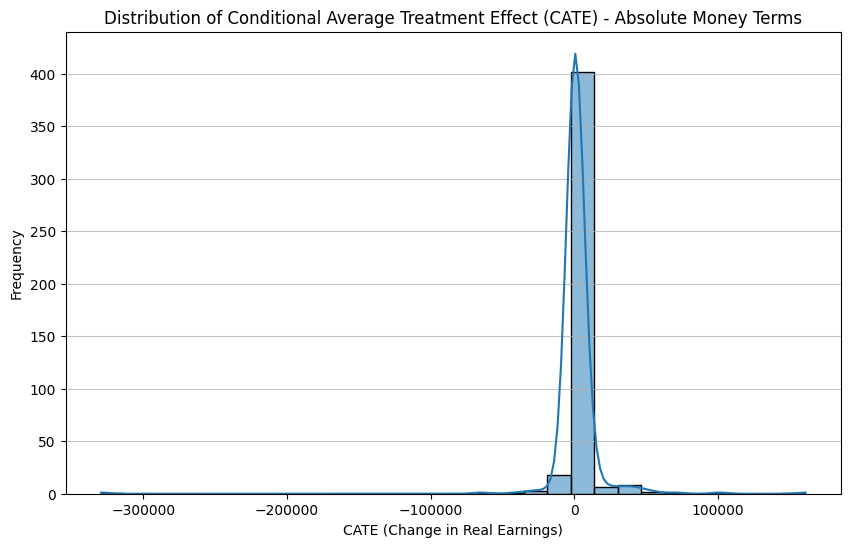

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Visualize the distribution of individual CATEs in absolute money terms
plt.figure(figsize=(10, 6))
sns.histplot(individual_absolute_difference, bins=30, kde=True)
plt.title('Distribution of Conditional Average Treatment Effect (CATE) - Absolute Money Terms')
plt.xlabel('CATE (Change in Real Earnings)')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.show()

In [ ]:
print(np.min(individual_absolute_difference))
print(np.max(individual_absolute_difference))
print(np.mean(individual_absolute_difference))

-329378.08827146114
160722.39572070033
1715.8618001209309


Let's visualize the distribution of these individual CATEs using a histogram to understand the heterogeneity of the treatment effect across the population.

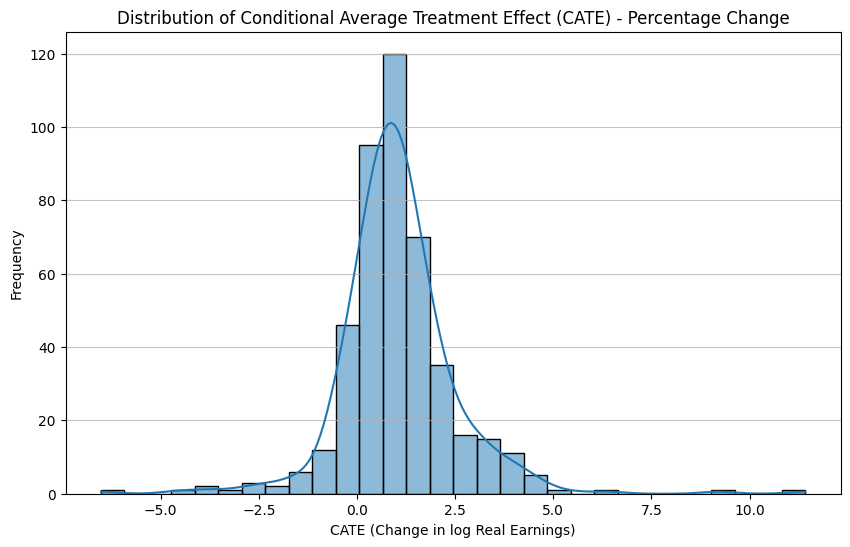

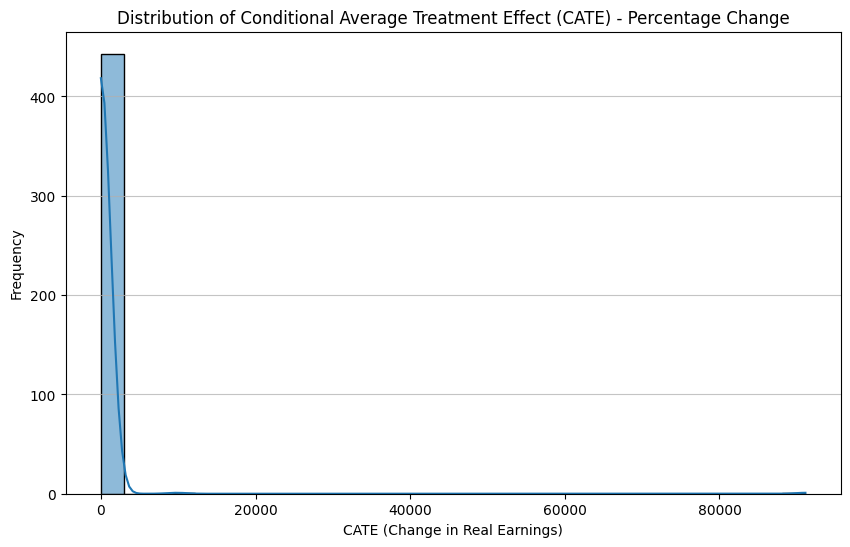

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Visualize the distribution of individual CATEs (percentage change)
plt.figure(figsize=(10, 6))
sns.histplot(cate_aipw, bins=30, kde=True)
plt.title('Distribution of Conditional Average Treatment Effect (CATE) - Percentage Change')
plt.xlabel('CATE (Change in log Real Earnings)')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.show()

# in decimal values:
cate_pc = (np.exp(cate_aipw)-1)
plt.figure(figsize=(10, 6))
sns.histplot(cate_pc, bins=30, kde=True)
plt.title('Distribution of Conditional Average Treatment Effect (CATE) - Percentage Change')
plt.xlabel('CATE (Change in Real Earnings)')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.show()

### Visualization
#### NOCHMAL ÜBERLEGEN, welche ich will & sinnvoll sind

Visualization of Data Signals: Correlation Heatmap

This heatmap displays the pairwise correlation coefficients between the key numerical and binary features in your dataset, including the log-transformed target variable (`lre78`) and the treatment variable (`treat`). A correlation value closer to 1 or -1 indicates a stronger linear relationship.

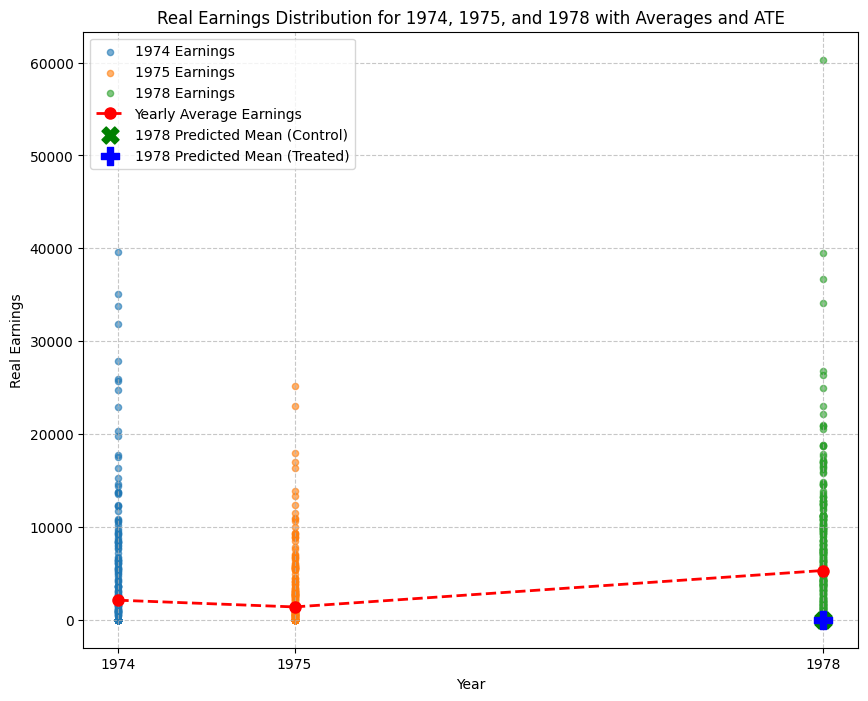

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Calculate yearly averages
mean_re74 = df['re74'].mean()
mean_re75 = df['re75'].mean()
mean_re78 = df['re78'].mean()

# Calculate the mean of predicted outcomes for control and treated groups in 1978
mean_m0_oof = np.mean(m0_oof)
mean_m1_oof = np.mean(m1_oof)

exp_ate=math.exp(ate_aipw_pc)

# Create a figure for log values
plt.figure(figsize=(10, 8))

# Scatter plot for lre74
plt.scatter(np.full_like(df['re74'], 1974), df['re74'], label='1974 Earnings', alpha=0.6, s=20)
# Scatter plot for lre75
plt.scatter(np.full_like(df['re75'], 1975), df['re75'], label='1975 Earnings', alpha=0.6, s=20)
# Scatter plot for lre78
plt.scatter(np.full_like(df['re78'], 1978), df['re78'], label='1978 Earnings', alpha=0.6, s=20)

# Plot yearly averages with a line
plt.plot([1974, 1975, 1978], [mean_re74, mean_re75, mean_re78], color='red', linestyle='--', linewidth=2, marker='o', markersize=8, label='Yearly Average Earnings')

# Add markers for predicted mean real earnings (m0_oof and m1_oof) for 1978
plt.scatter([1978], [mean_m0_oof], color='green', marker='X', s=150, label='1978 Predicted Mean (Control)', zorder=5)
plt.scatter([1978], [mean_m1_oof], color='blue', marker='P', s=150, label='1978 Predicted Mean (Treated)', zorder=5)

#plt.scatter([1978], [exp_ate], color='blue', marker='P', s=150, label='1978 Predicted Mean (Treated)', zorder=5)

plt.title('Real Earnings Distribution for 1974, 1975, and 1978 with Averages and ATE')
plt.xlabel('Year')
plt.ylabel('Real Earnings')
plt.xticks([1974, 1975, 1978]) # Ensure only these years are shown on x-axis
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.show()

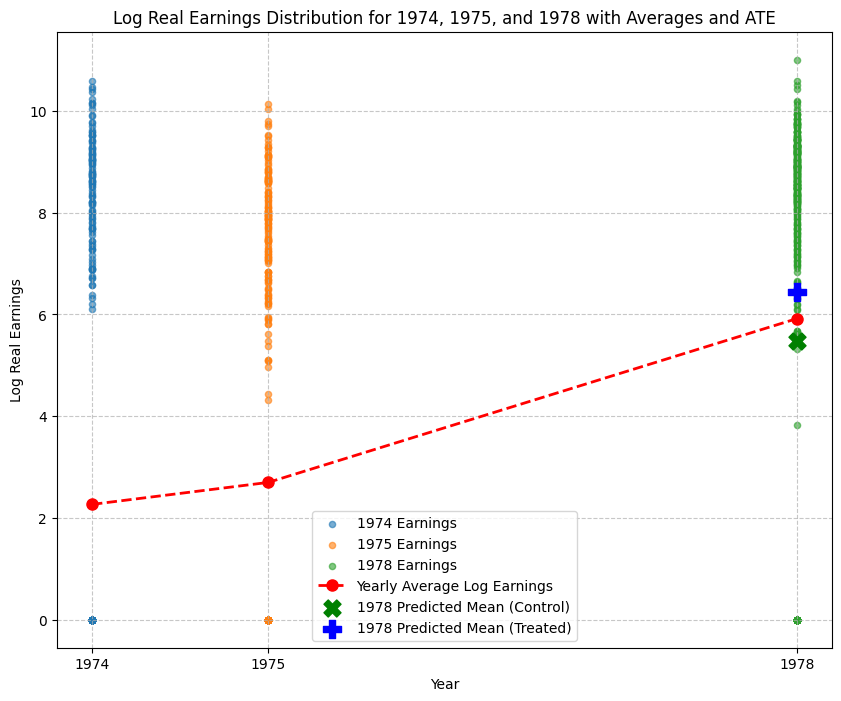

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Calculate yearly averages
mean_lre74 = df['lre74'].mean()
mean_lre75 = df['lre75'].mean()
mean_lre78 = df['lre78'].mean()

# Calculate the mean of predicted outcomes for control and treated groups in 1978
mean_m0_oof = np.mean(m0_oof)
mean_m1_oof = np.mean(m1_oof)

# Create a figure for log values
plt.figure(figsize=(10, 8))

# Scatter plot for lre74
plt.scatter(np.full_like(df['lre74'], 1974), df['lre74'], label='1974 Earnings', alpha=0.6, s=20)
# Scatter plot for lre75
plt.scatter(np.full_like(df['lre75'], 1975), df['lre75'], label='1975 Earnings', alpha=0.6, s=20)
# Scatter plot for lre78
plt.scatter(np.full_like(df['lre78'], 1978), df['lre78'], label='1978 Earnings', alpha=0.6, s=20)

# Plot yearly averages with a line
plt.plot([1974, 1975, 1978], [mean_lre74, mean_lre75, mean_lre78], color='red', linestyle='--', linewidth=2, marker='o', markersize=8, label='Yearly Average Log Earnings')

# Add markers for predicted mean real earnings (m0_oof and m1_oof) for 1978
plt.scatter([1978], [mean_m0_oof], color='green', marker='X', s=150, label='1978 Predicted Mean (Control)', zorder=5)
plt.scatter([1978], [mean_m1_oof], color='blue', marker='P', s=150, label='1978 Predicted Mean (Treated)', zorder=5)

plt.title('Log Real Earnings Distribution for 1974, 1975, and 1978 with Averages and ATE')
plt.xlabel('Year')
plt.ylabel('Log Real Earnings')
plt.xticks([1974, 1975, 1978]) # Ensure only these years are shown on x-axis
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.show()

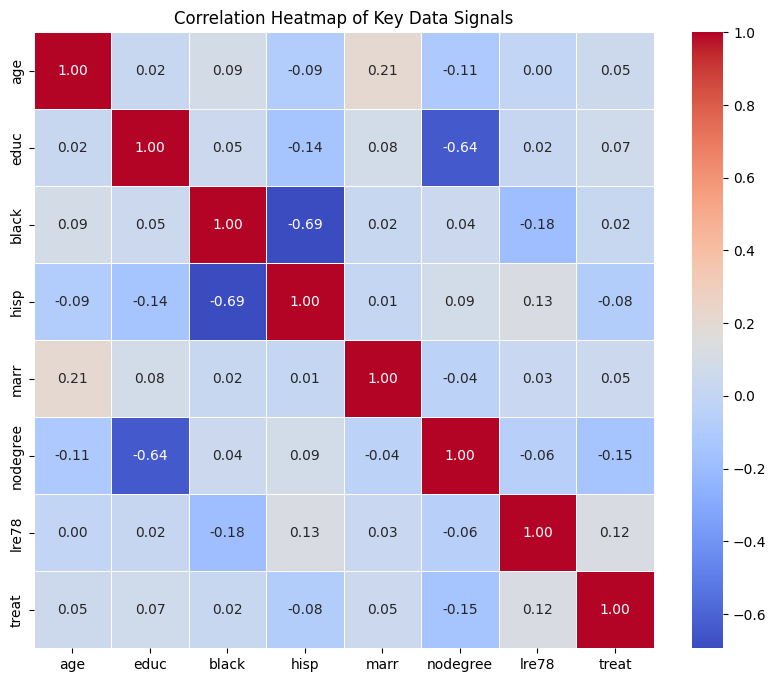

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select the relevant numerical and binary columns for correlation
# Assuming 'df' contains 'age', 'educ', 'black', 'hisp', 'marr', 'nodegree', 'lre78', 'treat'
selected_cols = ['age', 'educ', 'black', 'hisp', 'marr', 'nodegree', 'lre78', 'treat']
corr_matrix = df[selected_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Heatmap of Key Data Signals')
plt.show()

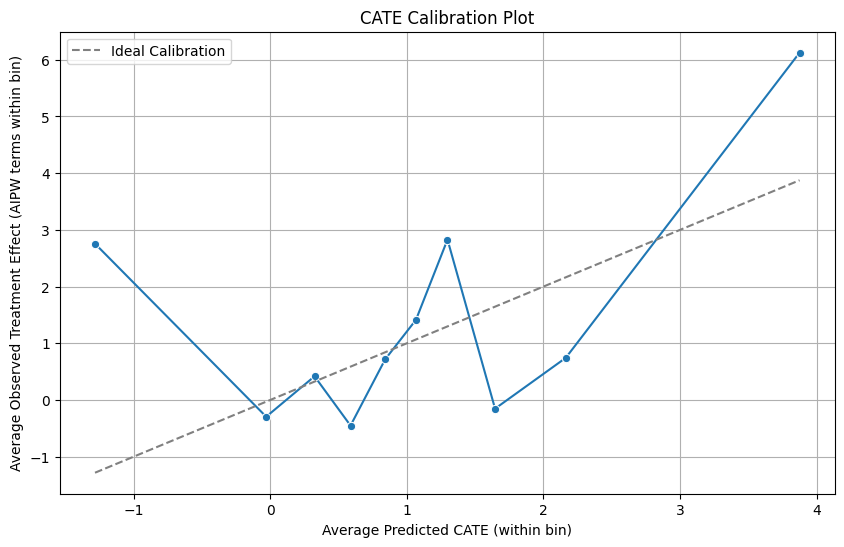

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Create a DataFrame for easier manipulation
cate_df = pd.DataFrame({
    'cate_aipw': cate_aipw,
    'aipw_terms': aipw_terms
})

# Sort by CATE for better binning and visualization
cate_df = cate_df.sort_values(by='cate_aipw').reset_index(drop=True)

# Define the number of bins (e.g., deciles)
num_bins = 10
cate_df['cate_bin'] = pd.qcut(cate_df['cate_aipw'], q=num_bins, labels=False, duplicates='drop')

# Calculate average predicted CATE and average 'observed' treatment effect (from AIPW terms) per bin
calibration_data = cate_df.groupby('cate_bin').agg(
    mean_predicted_cate=('cate_aipw', 'mean'),
    mean_observed_effect=('aipw_terms', 'mean')
).reset_index()

# Plotting the calibration curve
plt.figure(figsize=(10, 6))
sns.lineplot(x='mean_predicted_cate', y='mean_observed_effect', data=calibration_data, marker='o')
plt.plot([calibration_data['mean_predicted_cate'].min(), calibration_data['mean_predicted_cate'].max()],
         [calibration_data['mean_predicted_cate'].min(), calibration_data['mean_predicted_cate'].max()],
         linestyle='--', color='gray', label='Ideal Calibration') # Ideal line

plt.title('CATE Calibration Plot')
plt.xlabel('Average Predicted CATE (within bin)')
plt.ylabel('Average Observed Treatment Effect (AIPW terms within bin)')
plt.grid(True)
plt.legend()
plt.show()

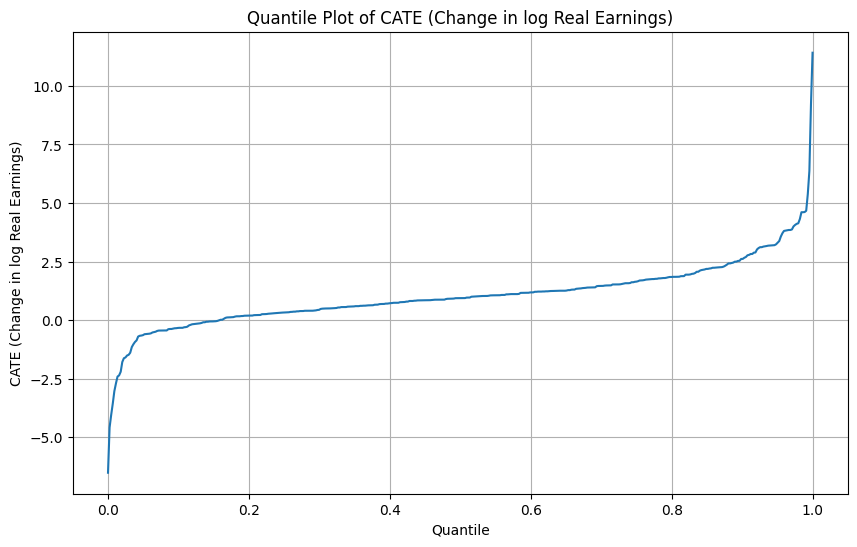

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Sort the CATE values
sorted_cate = np.sort(cate_aipw)

# Create an array of quantiles (e.g., from 0 to 1)
quantiles = np.linspace(0, 1, len(sorted_cate))

plt.figure(figsize=(10, 6))
plt.plot(quantiles, sorted_cate)
plt.title('Quantile Plot of CATE (Change in log Real Earnings)')
plt.xlabel('Quantile')
plt.ylabel('CATE (Change in log Real Earnings)')
plt.grid(True)
plt.show()

The qq plot (?) looks quite nice as most people have similar cates. However, there are some outliers at the tails

In [ ]:
A heatmap is typically used for visualizing relationships between multiple variables (e.g., a correlation matrix) or a 2D array. The `cate_aipw` variable is a 1-dimensional array of individual CATE values, so a heatmap is not the appropriate visualization type. We already have a histogram for the CATE distribution; do you want to try another visualization, or perhaps a heatmap showing correlations between CATE and other features?

Object `features` not found.


#### CATE distribution by 'black' dummy variable

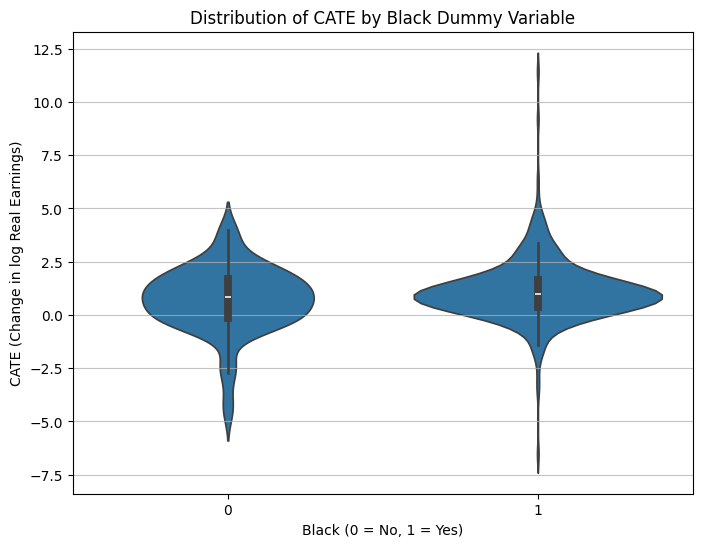

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure 'cate_aipw' is aligned with 'df' or the relevant data used for CATE calculation
# Assuming cate_aipw has the same index as the original df or can be mapped
# If df is the original DataFrame and cate_aipw is derived from it, we can simply add it.
# If not, a re-indexing or merging step might be needed.

# For simplicity, assuming `cate_aipw` length matches `df` length and order, or can be assigned to a new column.
# Let's create a temporary DataFrame for plotting
plot_df = pd.DataFrame({'CATE': cate_aipw, 'Black': df['black'].values})

plt.figure(figsize=(8, 6))
sns.violinplot(x='Black', y='CATE', data=plot_df)
plt.title('Distribution of CATE by Black Dummy Variable')
plt.xlabel('Black (0 = No, 1 = Yes)')
plt.ylabel('CATE (Change in log Real Earnings)')
plt.grid(axis='y', alpha=0.75)
plt.show()

#### CATE distribution by 'education' variable

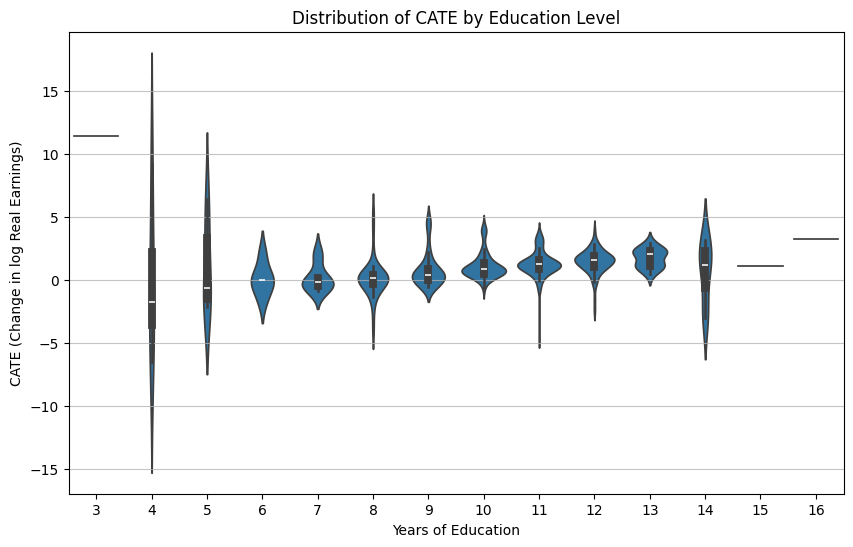

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Create a DataFrame for plotting, aligning CATE with the 'educ' feature
plot_df_educ = pd.DataFrame({'CATE': cate_aipw, 'Education': df['educ'].values})

plt.figure(figsize=(10, 6))
sns.violinplot(x='Education', y='CATE', data=plot_df_educ)
plt.title('Distribution of CATE by Education Level')
plt.xlabel('Years of Education')
plt.ylabel('CATE (Change in log Real Earnings)')
plt.grid(axis='y', alpha=0.75)
plt.show()

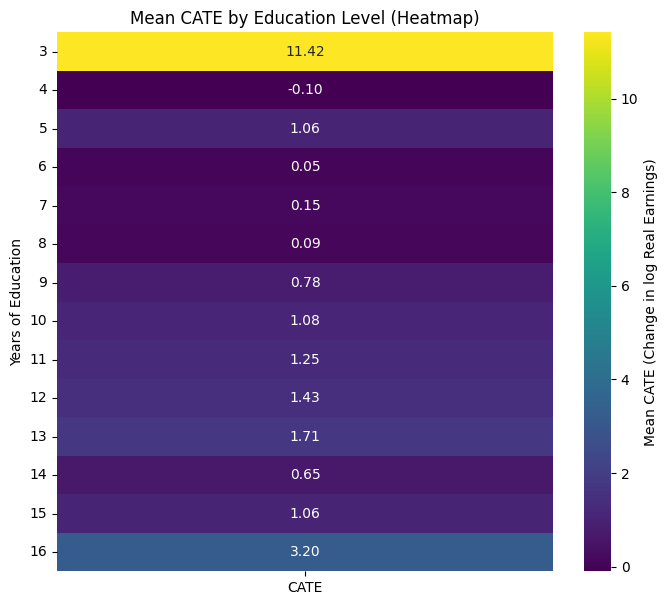

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Assuming plot_df_educ is already available from previous cells (e.g., 'cedbb6f4')
# plot_df_educ = pd.DataFrame({'CATE': cate_aipw, 'Education': df['educ'].values})

# Calculate the mean CATE for each education level
mean_cate_by_educ = plot_df_educ.groupby('Education')['CATE'].mean().reset_index()

# To create a heatmap, we can set 'Education' as the index and treat 'CATE' as the value.
# This will result in a single-column heatmap where each row corresponds to an education level.
# Reshape for heatmap: create a single-column DataFrame from the series
heatmap_data = mean_cate_by_educ.set_index('Education')

plt.figure(figsize=(8, 7)) # Adjust figure size for better readability
sns.heatmap(heatmap_data, annot=True, cmap='viridis', fmt=".2f", cbar_kws={'label': 'Mean CATE (Change in log Real Earnings)'})
plt.title('Mean CATE by Education Level (Heatmap)')
plt.ylabel('Years of Education')
plt.xlabel('') # No specific x-label needed as it's a single column
plt.yticks(rotation=0) # Ensure education labels are horizontal
plt.show()

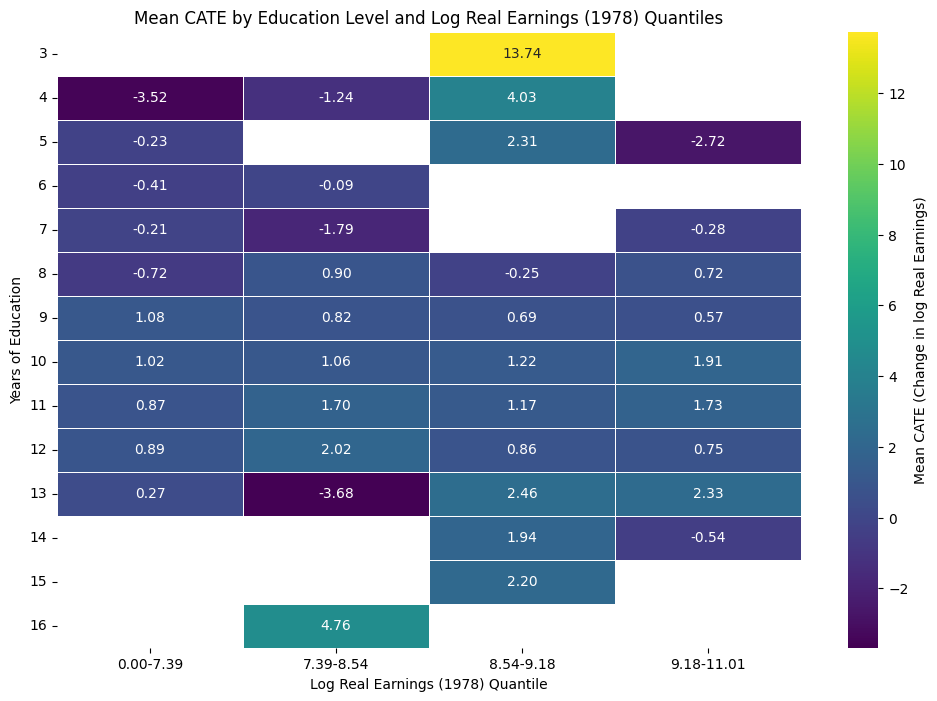

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Create a DataFrame for plotting, aligning CATE with 'educ' and 'lre78'
plot_df_full = pd.DataFrame({
    'CATE': cate_aipw,
    'Education': df['educ'].values,
    'lre78': df['lre78'].values
})

# Bin lre78 into quantiles for a 2D heatmap
# Using qcut to create equal-sized bins based on quantiles
plot_df_full['lre78_bin'] = pd.qcut(plot_df_full['lre78'], q=5, labels=False, duplicates='drop')

# Map bin labels to more descriptive ranges for the heatmap
# Get the actual bin edges
_, bins = pd.qcut(df['lre78'], q=5, retbins=True, duplicates='drop')
bin_labels = [f'{bins[i]:.2f}-{bins[i+1]:.2f}' for i in range(len(bins)-1)]

# Handle cases where duplicates='drop' might reduce the number of bins
# and thus the number of labels needed.
if len(bin_labels) > len(plot_df_full['lre78_bin'].unique()):
    bin_labels = bin_labels[:len(plot_df_full['lre78_bin'].unique())]

plot_df_full['lre78_bin_label'] = plot_df_full['lre78_bin'].map(lambda x: bin_labels[x])

# Calculate the mean CATE for each combination of education level and lre78 bin
heatmap_data_2d = plot_df_full.groupby(['Education', 'lre78_bin_label'])['CATE'].mean().unstack()

# Reorder columns (lre78_bin_label) to be in ascending order of the numerical bins
# This is important if pd.qcut doesn't naturally sort them when converting to labels
# Extract the lower bound of each bin for sorting
sorted_columns = sorted(heatmap_data_2d.columns, key=lambda x: float(x.split('-')[0]))
heatmap_data_2d = heatmap_data_2d[sorted_columns]

plt.figure(figsize=(12, 8))
sns.heatmap(heatmap_data_2d, annot=True, cmap='viridis', fmt=".2f", linewidths=.5,
            cbar_kws={'label': 'Mean CATE (Change in log Real Earnings)'})
plt.title('Mean CATE by Education Level and Log Real Earnings (1978) Quantiles')
plt.xlabel('Log Real Earnings (1978) Quantile')
plt.ylabel('Years of Education')
plt.yticks(rotation=0)
plt.show()

white gaps are missing datapoints

in first quantile: highest treatment effect for those with 9 & 10 years of education (positive but declining for more years of education), and lowest/negative CATE for those with only 4 years of education

in second quantile: positive ate for education years...

positive ATEs for education years 9-12, somethimes also for more years of education. But mean years of education is at around 10 years, so the CATEs for very low and very high years of education might be influenced by outliers / individual cases

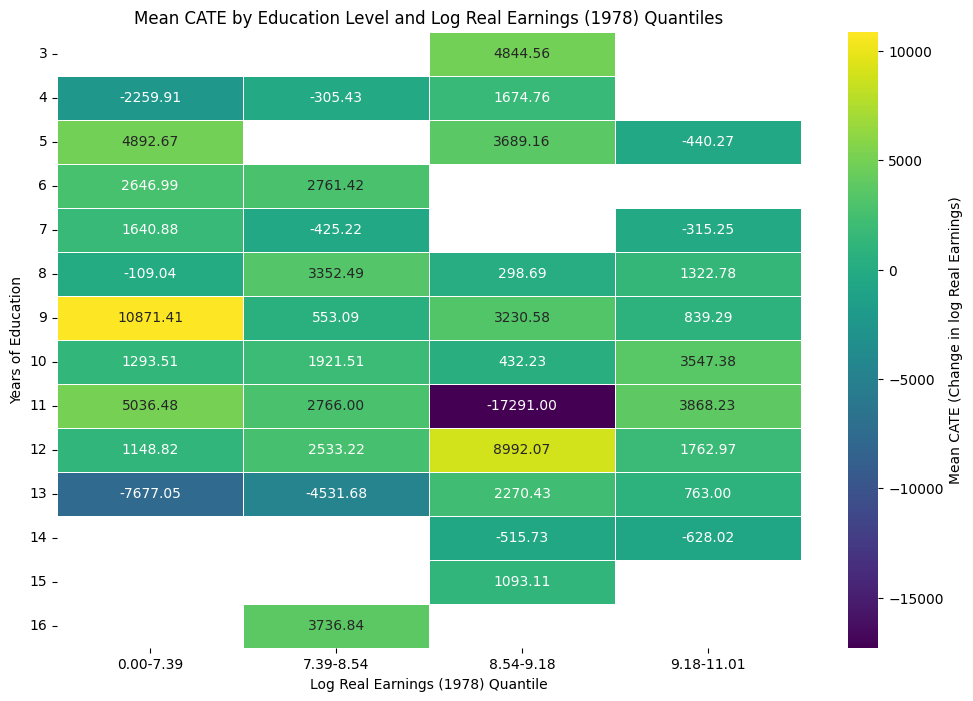

In [ ]:
# Create a DataFrame for plotting, aligning CATE with 'educ' and 'lre78'
plot_df_full = pd.DataFrame({
    'CATE': individual_absolute_difference,
    'Education': df['educ'].values,
    'lre78': df['lre78'].values
})

# Bin lre78 into quantiles for a 2D heatmap
# Using qcut to create equal-sized bins based on quantiles
plot_df_full['lre78_bin'] = pd.qcut(plot_df_full['lre78'], q=5, labels=False, duplicates='drop')

# Map bin labels to more descriptive ranges for the heatmap
# Get the actual bin edges
_, bins = pd.qcut(df['lre78'], q=5, retbins=True, duplicates='drop')
bin_labels = [f'{bins[i]:.2f}-{bins[i+1]:.2f}' for i in range(len(bins)-1)]

# Handle cases where duplicates='drop' might reduce the number of bins
# and thus the number of labels needed.
if len(bin_labels) > len(plot_df_full['lre78_bin'].unique()):
    bin_labels = bin_labels[:len(plot_df_full['lre78_bin'].unique())]

plot_df_full['lre78_bin_label'] = plot_df_full['lre78_bin'].map(lambda x: bin_labels[x])

# Calculate the mean CATE for each combination of education level and lre78 bin
heatmap_data_2d = plot_df_full.groupby(['Education', 'lre78_bin_label'])['CATE'].mean().unstack()

# Reorder columns (lre78_bin_label) to be in ascending order of the numerical bins
# This is important if pd.qcut doesn't naturally sort them when converting to labels
# Extract the lower bound of each bin for sorting
sorted_columns = sorted(heatmap_data_2d.columns, key=lambda x: float(x.split('-')[0]))
heatmap_data_2d = heatmap_data_2d[sorted_columns]

plt.figure(figsize=(12, 8))
sns.heatmap(heatmap_data_2d, annot=True, cmap='viridis', fmt=".2f", linewidths=.5,
            cbar_kws={'label': 'Mean CATE (Change in log Real Earnings)'})
plt.title('Mean CATE by Education Level and Log Real Earnings (1978) Quantiles')
plt.xlabel('Log Real Earnings (1978) Quantile')
plt.ylabel('Years of Education')
plt.yticks(rotation=0)
plt.show()

# --> eher nicht zeigen

#### Distributions of $m_0(X)$ and $m_1(X)$

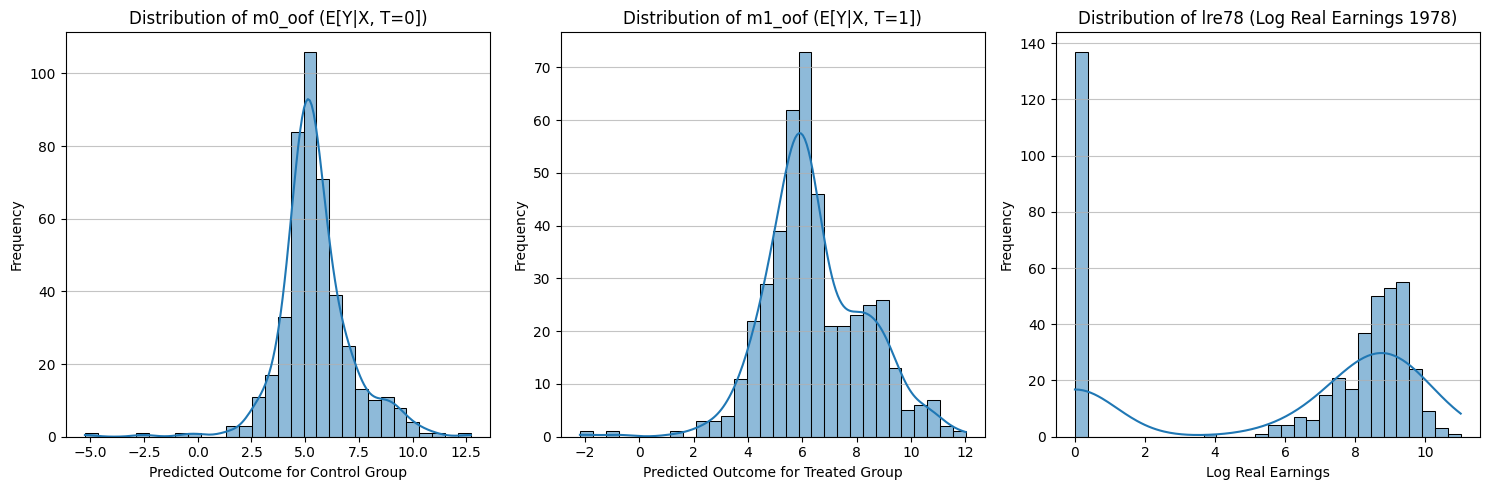

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(15, 5)) # Adjusted figure size to accommodate three subplots

plt.subplot(1, 3, 1) # Changed to 1 row, 3 columns, first plot
sns.histplot(m0_oof, bins=30, kde=True)
plt.title('Distribution of m0_oof (E[Y|X, T=0])')
plt.xlabel('Predicted Outcome for Control Group')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)

plt.subplot(1, 3, 2) # Changed to 1 row, 3 columns, second plot
sns.histplot(m1_oof, bins=30, kde=True)
plt.title('Distribution of m1_oof (E[Y|X, T=1])')
plt.xlabel('Predicted Outcome for Treated Group')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)

plt.subplot(1, 3, 3) # Added third subplot for lre78
sns.histplot(df['lre78'], bins=30, kde=True)
plt.title('Distribution of lre78 (Log Real Earnings 1978)')
plt.xlabel('Log Real Earnings')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)

plt.tight_layout()
plt.show()